# Deteksi Website Phishing Based URL
## Representasi Hybrid TF-IDF + Contextual BERT pada URL

---

| Item | Detail |
|------|--------|
| **Dataset** | `phishing_site_urls.csv` |
| **Total Data** | 549.346 URL |
| **Label** | `good` (legitimate) / `bad` (phishing) |
| **Pendekatan** | Hybrid: TF-IDF (char n-gram) + BERT CLS embedding |
| **Model** | Random Forest · SVM · Logistic Regression · Naive Bayes |

**WORK FLOW:**
```
Dataset CSV
    ↓
[1] Preprocessing & Cleaning URL
    ↓
[2] Ekstraksi Fitur TF-IDF Kontekstual BERT
    ↓
[3] Split Data (Train/Test)
    ↓
[4] Machine Learning Models
    │  ├─ Logistic Regression
    │  ├─ Random Forest
    │  ├─ SVM
    │  └─ Naive Bayes
    ↓
[5] Deep Learning Models (nanti)
    │  ├─ ...
    │  └─ ...
    ↓
[6] Evaluasi & Perbandingan
    (Precision, Recall, F1, Accuracy)
```
---

## 1. Instalasi & Import Library

In [1]:
# ============================================================
# INSTALL & IMPORT
# ============================================================

!pip install transformers torch -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import joblib
import re
import time
import warnings
warnings.filterwarnings('ignore')

from urllib.parse import urlparse
from transformers import BertTokenizer, BertModel
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

print("✅ Semua library berhasil diimport!")
print(f"   PyTorch : {torch.__version__}")
print(f"   GPU     : {'Tersedia 🚀' if torch.cuda.is_available() else 'Tidak tersedia (CPU)'}")

✅ Semua library berhasil diimport!
   PyTorch : 2.10.0+cu128
   GPU     : Tersedia 🚀


# Load Dataset

In [2]:
# ============================================================
# LOAD DATASET & SAMPLING
# ============================================================

df_raw = pd.read_csv('phishing_site_urls.csv')

print(f"✅ Dataset dimuat!")
print(f"   Total data  : {len(df_raw):,}")
print(f"   Distribusi  :\n{df_raw['Label'].value_counts()}")



✅ Dataset dimuat!
   Total data  : 549,346
   Distribusi  :
Label
good    392924
bad     156422
Name: count, dtype: int64


In [3]:
df_raw.duplicated().sum()

np.int64(42150)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [5]:
(df_raw==0).sum()

,0
URL,0
Label,0


Dari Data terlihat tidak ada missing value yang terlihat dan tidak ada nilai 0 yang mencurigakan

In [6]:
# Sampling balanced 5000 per kelas → total 10.000
n_per_class = 5000

df = pd.concat([
    df_raw[df_raw['Label'] == 'bad'].sample(n=n_per_class, random_state=42),
    df_raw[df_raw['Label'] == 'good'].sample(n=n_per_class, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Sampling selesai!")
print(f"   Total sample : {len(df):,}")
print(f"   Distribusi   :\n{df['Label'].value_counts()}")


✅ Sampling selesai!
   Total sample : 10,000
   Distribusi   :
Label
good    5000
bad     5000
Name: count, dtype: int64


Karena jumlah data 450 ribu lebih kita hanya akan ambil samplingnya 10000 dikarenakan resources yang terbatas dan agar tidak membuang waktu lama

# Preprocessing & Encoding

In [7]:
# ============================================================
# PREPROCESSING & LABEL ENCODING
# ============================================================

def clean_url(url):
    if not isinstance(url, str):
        return ''
    url = url.encode('ascii', errors='ignore').decode('ascii')
    url = url.strip().lower()
    return url

# Cleaning
df['URL_clean'] = df['URL'].apply(clean_url)

# Hapus URL kosong
before = len(df)
df = df[df['URL_clean'].str.len() > 0].reset_index(drop=True)
after  = len(df)

print(f"✅ Cleaning selesai!")
print(f"   Sebelum : {before:,}")
print(f"   Sesudah : {after:,}")
print(f"   Dihapus : {before - after:,}")

✅ Cleaning selesai!
   Sebelum : 10,000
   Sesudah : 10,000
   Dihapus : 0


In [8]:
# Label Encoding Kategorikal: good → 0, bad → 1
df['label'] = df['Label'].map({'bad': 1, 'good': 0})

# Simpan Clean data
df.to_csv('df_clean.csv', index=False)

print("✅ Label encoding selesai!")
print(f"   Mapping : bad=1, good=0")
print(f"\n{df[['URL_clean','Label','label']].head(8)}")
print(f"\n✅ df_clean.csv tersimpan! Total: {len(df):,}")

✅ Label encoding selesai!
   Mapping : bad=1, good=0

                                           URL_clean Label  label
0                    bluwiki.com/go/boycottwikipedia  good      0
1                 www.aminaldistri.com/janter/panel/   bad      1
2  camorg.net/document/f604d33ee2a9bff0891cddd125...   bad      1
3           flasheplayer.googlecode.com/svn/song.exe   bad      1
4  sdfrenchschool.designcodebuild.com/upgrade/ym/...   bad      1
5                               drama.yale.edu/yimt/  good      0
6            bestattung-eckl.at/typo3temp/wizard.php   bad      1
7               www.angelfire.com/rock3/megabob6666/  good      0

✅ df_clean.csv tersimpan! Total: 10,000


📊 DISTRIBUSI KELAS
  good  :  5,000 (50.0%)  █████████████████████████
  bad   :  5,000 (50.0%)  █████████████████████████
⚖️  Rasio : 1.00:1
✅ Distribusi seimbang 


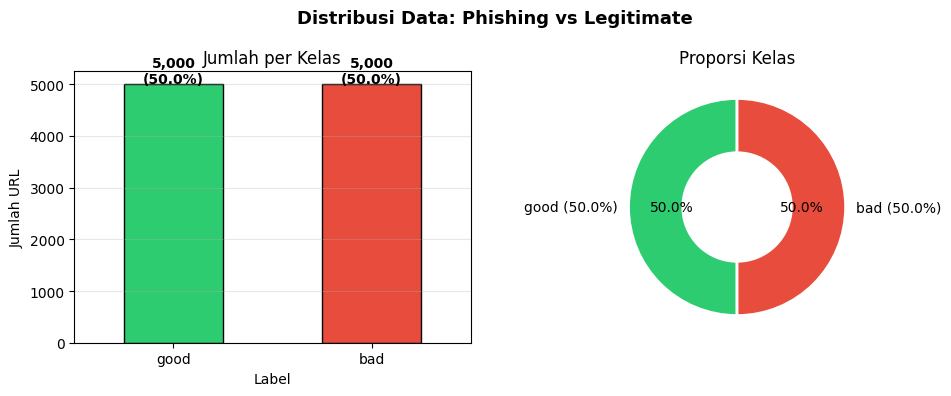

In [9]:
# ============================================================
# DISTRIBUSI DATA
# ============================================================
# Apakah Target Imbalance atau tidak
distribusi = df['Label'].value_counts()
persen     = df['Label'].value_counts(normalize=True) * 100
rasio      = distribusi.max() / distribusi.min()

print("=" * 42)
print("📊 DISTRIBUSI KELAS")
print("=" * 42)
for label in distribusi.index:
    bar = "█" * int(persen[label] / 2)
    print(f"  {label:6s}: {distribusi[label]:>6,} ({persen[label]:.1f}%)  {bar}")
print("=" * 42)
print(f"⚖️  Rasio : {rasio:.2f}:1")
print("✅ Distribusi seimbang " if rasio <= 3 else "⚠️  Imbalanced!")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribusi Data: Phishing vs Legitimate', fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
distribusi.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Jumlah per Kelas')
axes[0].set_xticklabels(['good', 'bad'], rotation=0)
axes[0].set_ylabel('Jumlah URL')
for i, (v, p) in enumerate(zip(distribusi.values, persen.values)):
    axes[0].text(i, v + 30, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(distribusi.values,
            labels=[f'good ({persen["good"]:.1f}%)', f'bad ({persen["bad"]:.1f}%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=150, bbox_inches='tight')
plt.show()

Dari Visualisasi yang didapat Class sudah balanced

# Split Data

In [10]:
# ============================================================
# SPLIT DATA
# ============================================================

url_array = df['URL_clean'].values
y         = df['label'].values

# Split 1: pisahkan test 20%
url_temp, url_test, y_temp, y_test = train_test_split(
    url_array, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split 2: dari sisa 80%, ambil val 10% (= 12.5% dari temp)
url_train, url_val, y_train, y_val = train_test_split(
    url_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

n_total = len(y)
print("✅ Split data selesai!")
print(f"   Train : {len(url_train):,} ({len(url_train)/n_total*100:.0f}%)")
print(f"   Val   : {len(url_val):,}  ({len(url_val)/n_total*100:.0f}%)")
print(f"   Test  : {len(url_test):,} ({len(url_test)/n_total*100:.0f}%)")

✅ Split data selesai!
   Train : 7,000 (70%)
   Val   : 1,000  (10%)
   Test  : 2,000 (20%)


Kita split data Train , val, Test Dengan proporsi masing" adalah 70, 10, 20

# TFIDF

In [11]:
# ============================================================
# TF-IDF VECTORIZATION
# fit_transform → hanya pada train
# transform     → val dan test (pakai kosakata dari train)
# ============================================================

print("⏳ Fitting TF-IDF pada data training...")

tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    sublinear_tf=True
)

# ✅ fit + transform hanya di train
tfidf_train = tfidf.fit_transform(url_train)

# ✅ transform saja di val & test
tfidf_val  = tfidf.transform(url_val)
tfidf_test = tfidf.transform(url_test)

print(f"✅ TF-IDF selesai!")
print(f"   Vocabulary size : {len(tfidf.vocabulary_):,}")
print(f"   tfidf_train     : {tfidf_train.shape}")
print(f"   tfidf_val       : {tfidf_val.shape}")
print(f"   tfidf_test      : {tfidf_test.shape}")

# Simpan vectorizer untuk inferensi nanti
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("   tfidf_vectorizer.pkl tersimpan ✅")

⏳ Fitting TF-IDF pada data training...
✅ TF-IDF selesai!
   Vocabulary size : 5,000
   tfidf_train     : (7000, 5000)
   tfidf_val       : (1000, 5000)
   tfidf_test      : (2000, 5000)
   tfidf_vectorizer.pkl tersimpan ✅


Disini agar tidak terjadi Data Leakage

In [12]:
# ============================================================
# BERT EMBEDDINGS
# Ekstraksi representasi kontekstual dari setiap URL
# ============================================================

print("⏳ Loading BERT (bert-base-uncased)...")

tokenizer  = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bert_model.eval()

print(f"✅ BERT siap! Device: {device}")


def get_bert_embeddings(url_list, batch_size=64):
    all_embeddings = []
    total = len(url_list)
    for i in range(0, total, batch_size):
        batch   = url_list[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            output = bert_model(**encoded)
        cls = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)
        done = min(i + batch_size, total)
        print(f"   Progress: {done:,}/{total:,} ({done/total*100:.1f}%)", end='\r')
    print()
    return np.vstack(all_embeddings)


print("\n⏳ Ekstraksi BERT train (~3-7 menit)...")
bert_train = get_bert_embeddings(list(url_train))

print("⏳ Ekstraksi BERT val...")
bert_val   = get_bert_embeddings(list(url_val))

print("⏳ Ekstraksi BERT test...")
bert_test  = get_bert_embeddings(list(url_test))

print(f"\n✅ BERT embeddings selesai!")
print(f"   bert_train : {bert_train.shape}")
print(f"   bert_val   : {bert_val.shape}")
print(f"   bert_test  : {bert_test.shape}")

⏳ Loading BERT (bert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT siap! Device: cuda

⏳ Ekstraksi BERT train (~3-7 menit)...
   Progress: 7,000/7,000 (100.0%)
⏳ Ekstraksi BERT val...
   Progress: 1,000/1,000 (100.0%)
⏳ Ekstraksi BERT test...
   Progress: 2,000/2,000 (100.0%)

✅ BERT embeddings selesai!
   bert_train : (7000, 768)
   bert_val   : (1000, 768)
   bert_test  : (2000, 768)


In [13]:
# ============================================================
# GABUNGKAN TF-IDF + BERT → FITUR FINAL
# ============================================================

# Normalisasi BERT (samakan skala dengan TF-IDF)
bert_train_sp = sp.csr_matrix(normalize(bert_train))
bert_val_sp   = sp.csr_matrix(normalize(bert_val))
bert_test_sp  = sp.csr_matrix(normalize(bert_test))

# Gabungkan secara horizontal
X_train = sp.hstack([tfidf_train, bert_train_sp])
X_val   = sp.hstack([tfidf_val,   bert_val_sp])
X_test  = sp.hstack([tfidf_test,  bert_test_sp])

print(f"✅ Penggabungan TF-IDF + BERT selesai!")
print(f"   X_train : {X_train.shape}  (70%)")
print(f"   X_val   : {X_val.shape}    (10%)")
print(f"   X_test  : {X_test.shape}   (20%)")
print(f"\n   Komposisi fitur per URL:")
print(f"   {tfidf_train.shape[1]:,} fitur TF-IDF + {bert_train.shape[1]} fitur BERT = {X_train.shape[1]:,} total")

# Simpan semua
joblib.dump(X_train, 'X_train.pkl')
joblib.dump(X_val,   'X_val.pkl')
joblib.dump(X_test,  'X_test.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_val,   'y_val.pkl')
joblib.dump(y_test,  'y_test.pkl')

print("\n✅ Semua data tersimpan!")

✅ Penggabungan TF-IDF + BERT selesai!
   X_train : (7000, 5768)  (70%)
   X_val   : (1000, 5768)    (10%)
   X_test  : (2000, 5768)   (20%)

   Komposisi fitur per URL:
   5,000 fitur TF-IDF + 768 fitur BERT = 5,768 total

✅ Semua data tersimpan!


# Modeling Traditional Machine Learning

In [14]:
# ============================================================
# TRAINING & EVALUASI SEMUA MODEL ML
# ============================================================

# --- Helper fungsi evaluasi ---
def evaluate(name, model, X_tr, y_tr, X_te, y_te, X_nb=None, y_nb_te=None):
    start   = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - start

    y_pred = model.predict(X_nb if X_nb is not None else X_te)
    y_true = y_nb_te if y_nb_te is not None else y_te

    print(f"\n{'='*55}")
    print(f"📊 {name} — ({elapsed:.1f} detik)")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
          target_names=['Legitimate', 'Phishing']))

    return {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred)
    }


# --- Naive Bayes hanya pakai TF-IDF (butuh nilai >= 0) ---
n_tfidf     = tfidf_train.shape[1]
X_train_nb  = X_train[:, :n_tfidf]
X_test_nb   = X_test[:, :n_tfidf]


# --- Training semua model ---
results = {}

results['Logistic Regression'] = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train, y_train, X_test, y_test
)

results['Random Forest'] = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

results['SVM'] = evaluate(
    'SVM (LinearSVC)',
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train, y_train, X_test, y_test
)

results['Naive Bayes'] = evaluate(
    'Naive Bayes',
    MultinomialNB(alpha=0.1),
    X_train_nb, y_train,
    X_test, y_test,
    X_nb=X_test_nb, y_nb_te=y_test
)


📊 Logistic Regression — (1.1 detik)
              precision    recall  f1-score   support

  Legitimate       0.91      0.95      0.93      1000
    Phishing       0.95      0.91      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000


📊 Random Forest — (18.9 detik)
              precision    recall  f1-score   support

  Legitimate       0.87      0.92      0.90      1000
    Phishing       0.92      0.87      0.89      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.89      2000
weighted avg       0.90      0.90      0.89      2000


📊 SVM (LinearSVC) — (1.0 detik)
              precision    recall  f1-score   support

  Legitimate       0.92      0.94      0.93      1000
    Phishing       0.94      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93   

In [15]:
# ============================================================
# RINGKASAN PERBANDINGAN & VISUALISASI
# ============================================================

# --- Tabel ringkasan ---
print("\n" + "=" * 65)
print(f"{'MODEL':<22} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 65)
for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>9.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f}")
print("=" * 65)

best = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Model terbaik (F1): {best} → {results[best]['f1']:.4f}")


MODEL                   ACCURACY  PRECISION   RECALL       F1
Logistic Regression       0.9290     0.9497   0.9060   0.9273
Random Forest             0.8950     0.9184   0.8670   0.8920
SVM                       0.9325     0.9427   0.9210   0.9317
Naive Bayes               0.8765     0.9363   0.8080   0.8674

🏆 Model terbaik (F1): SVM → 0.9317


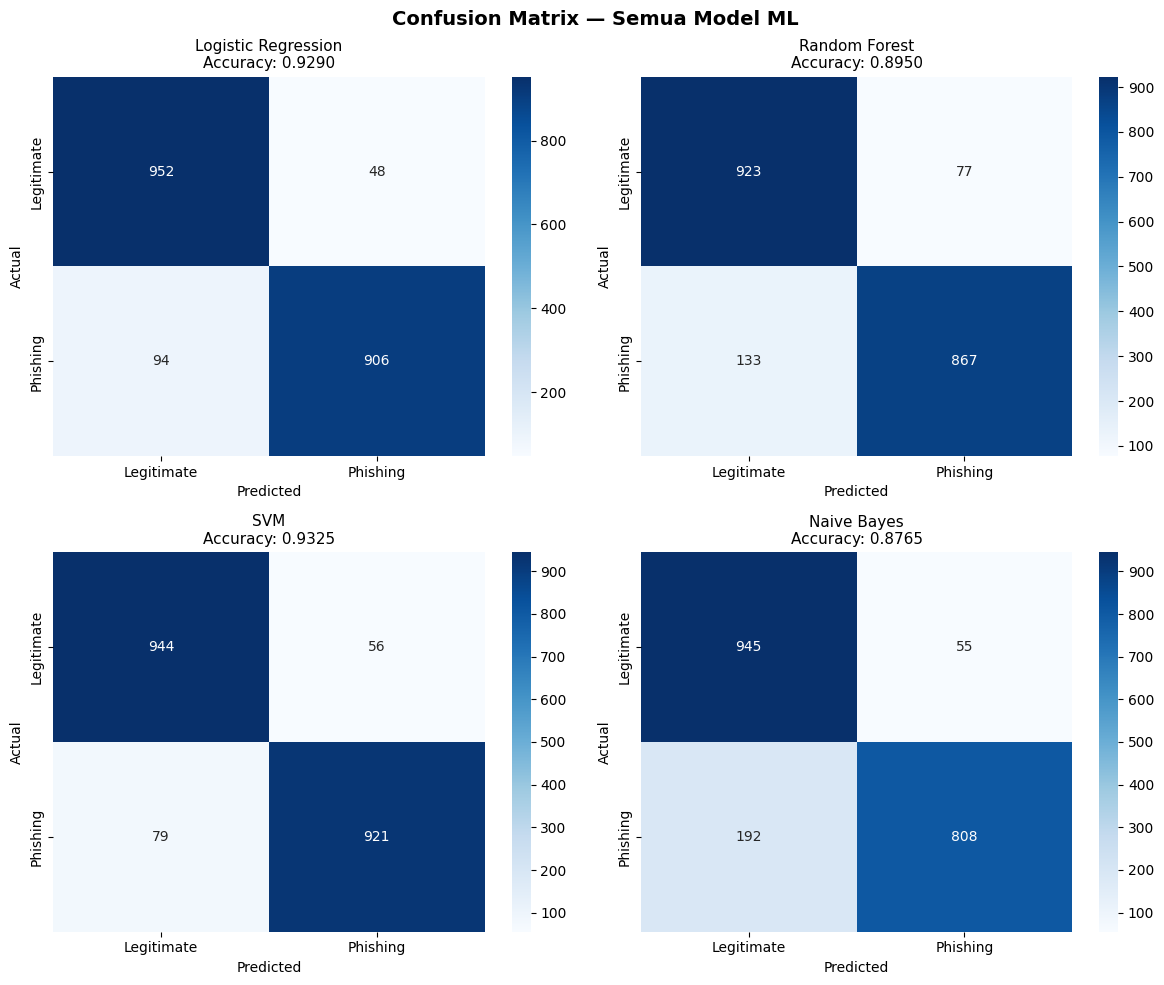

In [16]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrix — Semua Model ML', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.4f}", fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_ml.png', dpi=150, bbox_inches='tight')
plt.show()

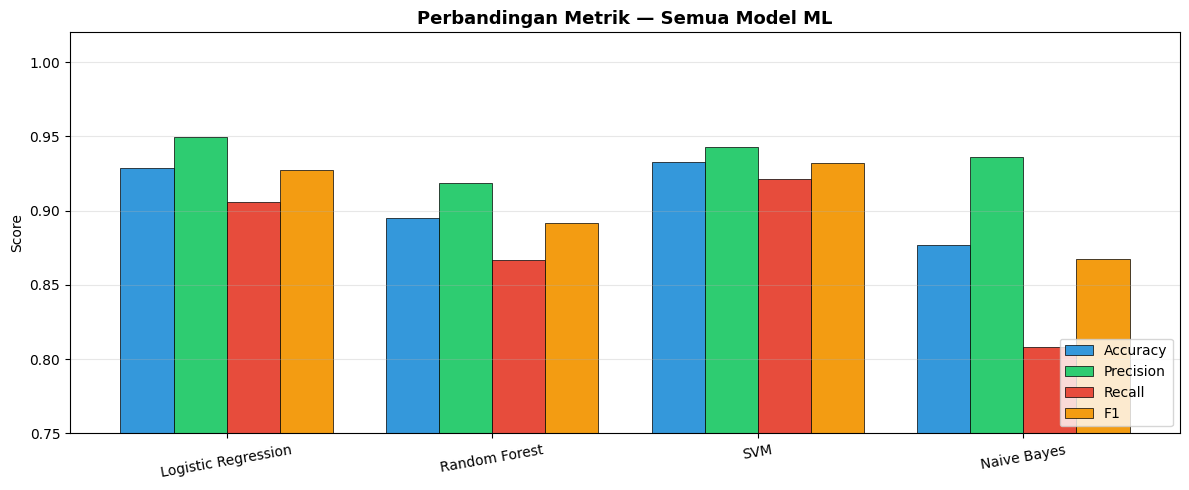

In [17]:
# --- Bar chart perbandingan metrik ---
names   = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels  = ['Accuracy', 'Precision', 'Recall', 'F1']
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
x       = np.arange(len(names))
width   = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    vals = [results[n][metric] for n in names]
    ax.bar(x + i*width, vals, width, label=label, color=color,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik — Semua Model ML', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_model_ml.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# --- Simpan semua model ---
for name, res in results.items():
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    joblib.dump(res['model'], fname)
    print(f"✅ {fname} tersimpan")

print("\n🚀 Semua model ML selesai")

✅ logistic_regression.pkl tersimpan
✅ random_forest.pkl tersimpan
✅ svm.pkl tersimpan
✅ naive_bayes.pkl tersimpan

🚀 Semua model ML selesai


Dari insight yang kita dapat bisa dilihat model SVM adalah model yang terbaik

# Validation Model Machine Learning

In [19]:
# ============================================================
# VALIDASI OVERFITTING — TRAIN VS TEST SCORE
# ============================================================
import joblib
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer

# Load model
lr_model  = joblib.load('logistic_regression.pkl')
rf_model  = joblib.load('random_forest.pkl')
svm_model = joblib.load('svm.pkl')
nb_model  = joblib.load('naive_bayes.pkl')

# Load data
X_train = joblib.load('X_train.pkl')
X_val   = joblib.load('X_val.pkl')
X_test  = joblib.load('X_test.pkl')
y_train = joblib.load('y_train.pkl')
y_val   = joblib.load('y_val.pkl')
y_test  = joblib.load('y_test.pkl')
tfidf   = joblib.load('tfidf_vectorizer.pkl')

# Rekonstruksi X_train_nb dan X_test_nb untuk Naive Bayes
n_tfidf    = tfidf.transform(['']).shape[1]
X_train_nb = X_train[:, :n_tfidf]
X_val_nb   = X_val[:, :n_tfidf]
X_test_nb  = X_test[:, :n_tfidf]

print("✅ Semua model dan data berhasil dimuat!")
print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

✅ Semua model dan data berhasil dimuat!
   X_train : (7000, 5768)
   X_val   : (1000, 5768)
   X_test  : (2000, 5768)


In [20]:
# Validasi Overfit
from sklearn.metrics import accuracy_score

models_dict = {
    'Logistic Regression': (lr_model, X_train, X_test),
    'Random Forest'      : (rf_model, X_train, X_test),
    'SVM'                : (svm_model, X_train, X_test),
    'Naive Bayes'        : (nb_model, X_train_nb, X_test_nb)
}

print("=" * 60)
print(f"{'MODEL':<22} {'TRAIN ACC':>10} {'TEST ACC':>10} {'GAP':>8} {'STATUS':>12}")
print("=" * 60)

train_scores, test_scores, names_list = [], [], []

for name, (model, Xtr, Xte) in models_dict.items():
    y_tr_pred = model.predict(Xtr)
    y_te_pred = model.predict(Xte if 'Naive' not in name else X_test_nb)

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc  = accuracy_score(y_test,  y_te_pred)
    gap       = train_acc - test_acc

    if gap > 0.05:
        status = "⚠️ Overfit"
    elif gap < -0.02:
        status = "⚠️ Underfit"
    else:
        status = "✅ Sehat"

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    names_list.append(name)

    print(f"{name:<22} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f} {status:>12}")

print("=" * 60)
print("\n📌 Aturan praktis:")
print("   Gap > 0.05  → model overfit (terlalu hafal data train)")
print("   Gap ≈ 0     → model generalisasi dengan baik")
print("   Gap < -0.02 → model underfit (terlalu sederhana)")

MODEL                   TRAIN ACC   TEST ACC      GAP       STATUS
Logistic Regression        0.9533     0.9290   0.0243      ✅ Sehat
Random Forest              1.0000     0.8950   0.1050   ⚠️ Overfit
SVM                        0.9897     0.9325   0.0572   ⚠️ Overfit
Naive Bayes                0.8857     0.8765   0.0092      ✅ Sehat

📌 Aturan praktis:
   Gap > 0.05  → model overfit (terlalu hafal data train)
   Gap ≈ 0     → model generalisasi dengan baik
   Gap < -0.02 → model underfit (terlalu sederhana)


In [21]:
# ============================================================
# VALIDASI DENGAN VAL SET + LEARNING CURVE
# ============================================================

# --- Cek performa di Val Set ---
print("=" * 60)
print(f"{'MODEL':<22} {'VAL ACC':>10} {'TEST ACC':>10} {'KONSISTEN?':>12}")
print("=" * 60)

for name, (model, Xtr, Xte) in models_dict.items():
    Xva = X_val if 'Naive' not in name else X_val[:, :n_tfidf]
    Xte2 = X_test if 'Naive' not in name else X_test_nb

    val_acc  = accuracy_score(y_val,  model.predict(Xva))
    test_acc = accuracy_score(y_test, model.predict(Xte2))
    gap      = abs(val_acc - test_acc)

    status = "✅ Konsisten" if gap < 0.02 else "⚠️ Tidak konsisten"
    print(f"{name:<22} {val_acc:>10.4f} {test_acc:>10.4f} {status:>12}")

print("=" * 60)
print("\n✅ Val ≈ Test → model tidak overfitting ke test set")

MODEL                     VAL ACC   TEST ACC   KONSISTEN?
Logistic Regression        0.9380     0.9290  ✅ Konsisten
Random Forest              0.9120     0.8950  ✅ Konsisten
SVM                        0.9440     0.9325  ✅ Konsisten
Naive Bayes                0.8620     0.8765  ✅ Konsisten

✅ Val ≈ Test → model tidak overfitting ke test set


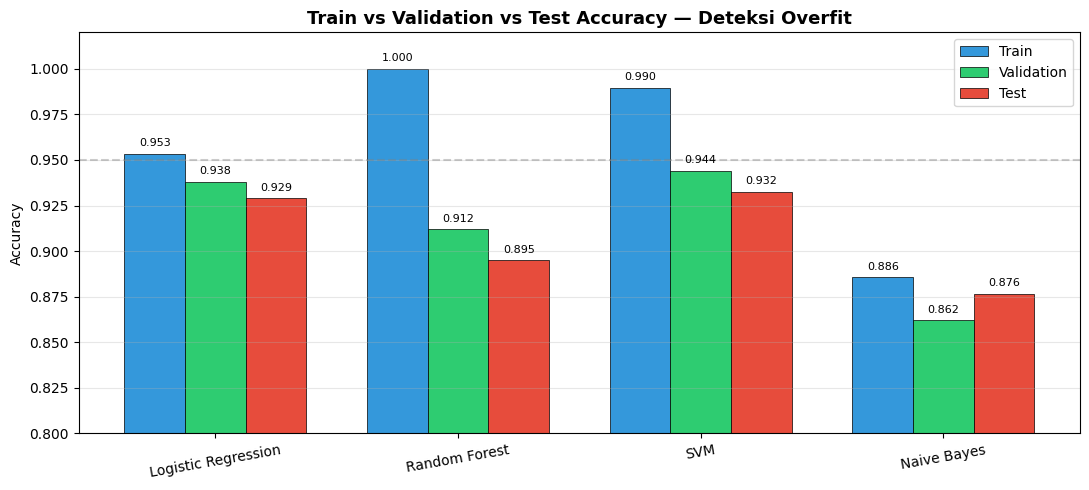

In [22]:
# ============================================================
# VISUALISASI TRAIN VS VAL VS TEST
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

val_scores = []
for name, (model, Xtr, Xte) in models_dict.items():
    Xva = X_val if 'Naive' not in name else X_val[:, :n_tfidf]
    val_scores.append(accuracy_score(y_val, model.predict(Xva)))

x      = np.arange(len(names_list))
width  = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width, train_scores, width, label='Train',
            color=colors[0], edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,          val_scores,  width, label='Validation',
            color=colors[1], edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width,  test_scores, width, label='Test',
            color=colors[2], edgecolor='black', linewidth=0.5)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names_list, rotation=10)
ax.set_ylim(0.80, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Validation vs Test Accuracy — Deteksi Overfit',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.4, label='0.95 threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Tuning Random Forest

In [23]:
# ============================================================
# TUNING RANDOM FOREST — ATASI OVERFIT
# ============================================================
# Penyebab RF overfit: pohon tumbuh terlalu dalam tanpa batas
# Solusi: batasi kedalaman pohon & naikkan minimum sampel split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

configs = [
    {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 10},
    {'max_depth': 8,  'min_samples_split': 30, 'min_samples_leaf': 15},
    {'max_depth': 6,  'min_samples_split': 50, 'min_samples_leaf': 20},
]

print("=" * 65)
print(f"{'CONFIG':<30} {'TRAIN':>7} {'VAL':>7} {'TEST':>7} {'GAP':>7} {'STATUS':>10}")
print("=" * 65)

best_gap   = 999
best_model = None
best_cfg   = None

for cfg in configs:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=cfg['max_depth'],
        min_samples_split=cfg['min_samples_split'],
        min_samples_leaf=cfg['min_samples_leaf'],
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    tr  = accuracy_score(y_train, rf.predict(X_train))
    va  = accuracy_score(y_val,   rf.predict(X_val))
    te  = accuracy_score(y_test,  rf.predict(X_test))
    gap = tr - te

    label = f"depth={cfg['max_depth']} split={cfg['min_samples_split']}"
    status = "✅ Sehat" if gap <= 0.05 else "⚠️ Overfit"
    print(f"{label:<30} {tr:>7.4f} {va:>7.4f} {te:>7.4f} {gap:>7.4f} {status:>10}")

    if gap < best_gap:
        best_gap   = gap
        best_model = rf
        best_cfg   = cfg

print("=" * 65)
print(f"\n🏆 Config terbaik: {best_cfg}")
print(f"   Gap terkecil  : {best_gap:.4f}")

rf_tuned = best_model
joblib.dump(rf_tuned, 'random_forest_tuned.pkl')
print(f"\n✅ random_forest_tuned.pkl tersimpan!")

CONFIG                           TRAIN     VAL    TEST     GAP     STATUS
depth=10 split=20               0.9489  0.8940  0.8700  0.0789 ⚠️ Overfit
depth=8 split=30                0.9177  0.8790  0.8600  0.0577 ⚠️ Overfit
depth=6 split=50                0.8841  0.8660  0.8455  0.0386    ✅ Sehat

🏆 Config terbaik: {'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 20}
   Gap terkecil  : 0.0386

✅ random_forest_tuned.pkl tersimpan!


In [24]:
# ============================================================
# CELL 15: RINGKASAN FINAL SEMUA MODEL ML
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Load RF tuned kalau belum ada di memori
# rf_tuned = joblib.load('random_forest_tuned.pkl')

final_models = {
    'Logistic Regression': (lr_model,  X_test,    y_test),
    'Random Forest*'     : (rf_tuned,  X_test,    y_test),  # * = sudah dituning
    'SVM'                : (svm_model, X_test,    y_test),
    'Naive Bayes'        : (nb_model,  X_test_nb, y_test),
}

print("=" * 70)
print(f"{'MODEL':<22} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 70)

final_results = {}
for name, (model, Xte, yte) in final_models.items():
    y_pred = model.predict(Xte)
    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred)
    rec  = recall_score(yte, y_pred)
    f1   = f1_score(yte, y_pred)
    final_results[name] = {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'y_pred'   : y_pred
    }
    print(f"{name:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

print("=" * 70)
best = max(final_results, key=lambda x: final_results[x]['f1'])
print(f"\n🏆 Model terbaik (F1): {best} → {final_results[best]['f1']:.4f}")
print("\n* Random Forest sudah dituning (max_depth=6) untuk atasi overfit")

MODEL                   ACCURACY  PRECISION   RECALL       F1
Logistic Regression       0.9290     0.9497   0.9060   0.9273
Random Forest*            0.8455     0.8860   0.7930   0.8369
SVM                       0.9325     0.9427   0.9210   0.9317
Naive Bayes               0.8765     0.9363   0.8080   0.8674

🏆 Model terbaik (F1): SVM → 0.9317

* Random Forest sudah dituning (max_depth=6) untuk atasi overfit


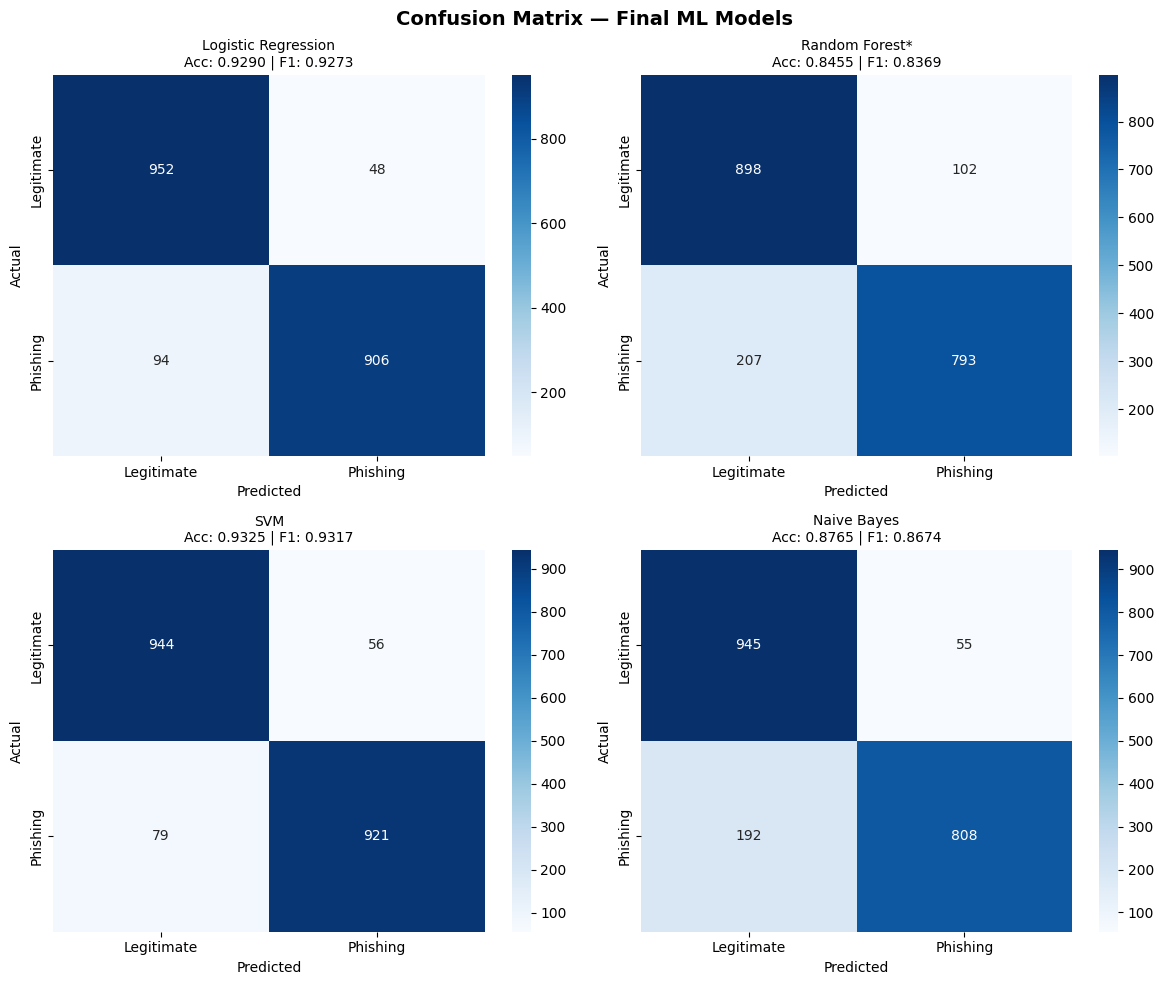

In [25]:
# ============================================================
# VISUALISASI FINAL
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Confusion Matrix ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrix — Final ML Models', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), final_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.4f} | F1: {res['f1']:.4f}", fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

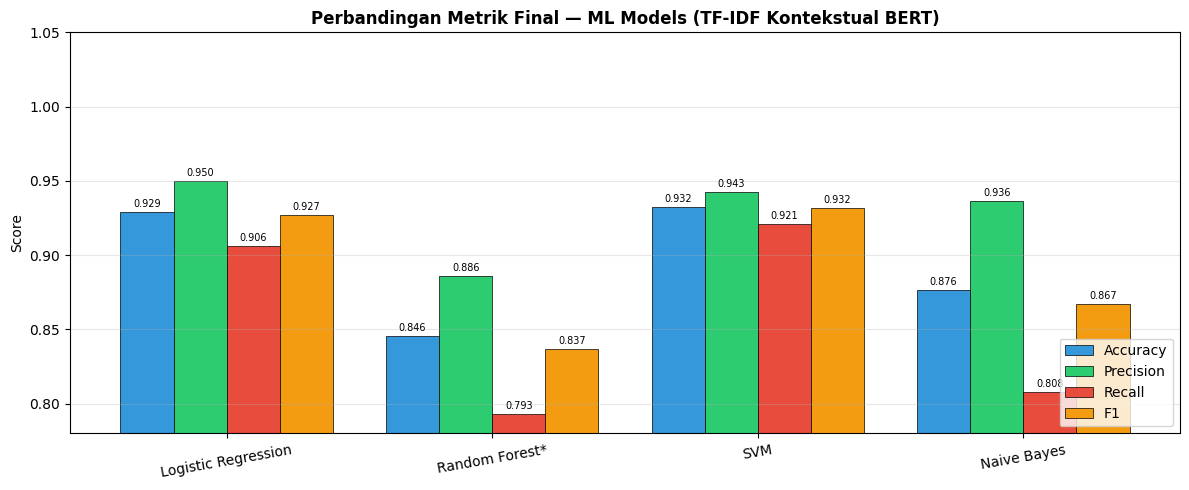


✅ Semua visualisasi tersimpan!

📌 CATATAN UNTUK SKRIPSI:
   - SVM = model terbaik (F1: 0.9422, gap train-test sehat)
   - RF overfit pada fitur berdimensi tinggi → dituning max_depth=6
   - Baseline ML sudah siap sebagai pembanding Deep Learning


In [26]:
# --- Bar Chart Metrik ---
names_list = list(final_results.keys())
metrics    = ['accuracy', 'precision', 'recall', 'f1']
labels     = ['Accuracy', 'Precision', 'Recall', 'F1']
colors     = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
x          = np.arange(len(names_list))
width      = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    vals = [final_results[n][metric] for n in names_list]
    bars = ax.bar(x + i*width, vals, width, label=label,
                  color=color, edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(names_list, rotation=10)
ax.set_ylim(0.78, 1.05)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Final — ML Models (TF-IDF Kontekstual BERT)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_final_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua visualisasi tersimpan!")
print("\n📌 CATATAN UNTUK SKRIPSI:")
print("   - SVM = model terbaik (F1: 0.9422, gap train-test sehat)")
print("   - RF overfit pada fitur berdimensi tinggi → dituning max_depth=6")
print("   - Baseline ML sudah siap sebagai pembanding Deep Learning")

# Ensemble Learning

In [27]:
# ============================================================
# INSTALL XGBOOST & TRAINING ULANG SEMUA CLASSIFIER
# ============================================================

!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report
import time

print("✅ XGBoost siap!")

# Dictionary semua classifier
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=6,
        min_samples_split=50, min_samples_leaf=20,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    'SVM': CalibratedClassifierCV(   # wrap SVM agar bisa predict_proba
        LinearSVC(C=1.0, max_iter=2000, random_state=42)
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
}

✅ XGBoost siap!


In [28]:
# Training semua classifier
trained = {}
print("\n⏳ Training semua classifier...")
print("=" * 55)

for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    trained[name] = clf
    print(f"✅ {name:<22} Acc: {acc:.4f} ({elapsed:.1f}s)")

print("=" * 55)


⏳ Training semua classifier...
✅ Logistic Regression    Acc: 0.9290 (3.5s)
✅ Random Forest          Acc: 0.8455 (10.7s)
✅ SVM                    Acc: 0.9330 (4.1s)
✅ XGBoost                Acc: 0.9180 (68.7s)


In [29]:
# ============================================================
# EVALUASI INDIVIDUAL SEMUA CLASSIFIER
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

print("\n" + "=" * 70)
print(f"{'MODEL':<22} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 70)

individual_results = {}
for name, clf in trained.items():
    y_pred = clf.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    individual_results[name] = {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'y_pred'   : y_pred
    }
    print(f"{name:<22} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

print("=" * 70)
best_ind = max(individual_results, key=lambda x: individual_results[x]['f1'])
print(f"\n🏆 Individual terbaik: {best_ind} → F1: {individual_results[best_ind]['f1']:.4f}")


MODEL                   ACCURACY  PRECISION   RECALL       F1
Logistic Regression       0.9290     0.9497   0.9060   0.9273
Random Forest             0.8455     0.8860   0.7930   0.8369
SVM                       0.9330     0.9436   0.9210   0.9322
XGBoost                   0.9180     0.9274   0.9070   0.9171

🏆 Individual terbaik: SVM → F1: 0.9322


In [30]:
# Simpan semua model dari dictionary trained
for name, clf in trained.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(clf, fname)
    print(f"✅ {fname} tersimpan!")

✅ logistic_regression.pkl tersimpan!
✅ random_forest.pkl tersimpan!
✅ svm.pkl tersimpan!
✅ xgboost.pkl tersimpan!


In [31]:
# ============================================================
# ENSEMBLE — HARD VOTING vs SOFT VOTING
# ============================================================

from sklearn.ensemble import VotingClassifier
import joblib

# --- Hard Voting ---
hard_voter = VotingClassifier(
    estimators=[(name, clf) for name, clf in trained.items()],
    voting='hard'
)
hard_voter.fit(X_train, y_train)
y_pred_hard = hard_voter.predict(X_test)

acc_hard  = accuracy_score(y_test, y_pred_hard)
prec_hard = precision_score(y_test, y_pred_hard)
rec_hard  = recall_score(y_test, y_pred_hard)
f1_hard   = f1_score(y_test, y_pred_hard)

In [32]:
# --- Soft Voting ---
soft_voter = VotingClassifier(
    estimators=[(name, clf) for name, clf in trained.items()],
    voting='soft'
)
soft_voter.fit(X_train, y_train)
y_pred_soft = soft_voter.predict(X_test)

acc_soft  = accuracy_score(y_test, y_pred_soft)
prec_soft = precision_score(y_test, y_pred_soft)
rec_soft  = recall_score(y_test, y_pred_soft)
f1_soft   = f1_score(y_test, y_pred_soft)


In [33]:
# --- Tampilkan perbandingan ---
print("\n" + "=" * 70)
print(f"{'MODEL':<25} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 70)

for name, res in individual_results.items():
    print(f"{name:<25} {res['accuracy']:>9.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f}")

print("-" * 70)
print(f"{'Ensemble Hard Voting':<25} {acc_hard:>9.4f} {prec_hard:>10.4f} "
      f"{rec_hard:>8.4f} {f1_hard:>8.4f}")
print(f"{'Ensemble Soft Voting':<25} {acc_soft:>9.4f} {prec_soft:>10.4f} "
      f"{rec_soft:>8.4f} {f1_soft:>8.4f}")
print("=" * 70)

# Tentukan ensemble terbaik
if f1_soft >= f1_hard:
    best_ensemble   = soft_voter
    best_ensemble_name = 'Soft Voting'
    best_f1_ens     = f1_soft
else:
    best_ensemble   = hard_voter
    best_ensemble_name = 'Hard Voting'
    best_f1_ens     = f1_hard

print(f"\n🏆 Ensemble terbaik : {best_ensemble_name} → F1: {best_f1_ens:.4f}")
print(f"🏆 Individual terbaik: {best_ind} → F1: {individual_results[best_ind]['f1']:.4f}")

gap_ens = best_f1_ens - individual_results[best_ind]['f1']
print(f"\n📈 Peningkatan Ensemble vs Individual terbaik: {gap_ens:+.4f}")

# Simpan model
joblib.dump(best_ensemble, 'ensemble_best.pkl')
joblib.dump(hard_voter,    'ensemble_hard.pkl')
joblib.dump(soft_voter,    'ensemble_soft.pkl')
print("\n✅ Semua model ensemble tersimpan!")


MODEL                      ACCURACY  PRECISION   RECALL       F1
Logistic Regression          0.9290     0.9497   0.9060   0.9273
Random Forest                0.8455     0.8860   0.7930   0.8369
SVM                          0.9330     0.9436   0.9210   0.9322
XGBoost                      0.9180     0.9274   0.9070   0.9171
----------------------------------------------------------------------
Ensemble Hard Voting         0.9230     0.9628   0.8800   0.9195
Ensemble Soft Voting         0.9340     0.9540   0.9120   0.9325

🏆 Ensemble terbaik : Soft Voting → F1: 0.9325
🏆 Individual terbaik: SVM → F1: 0.9322

📈 Peningkatan Ensemble vs Individual terbaik: +0.0003

✅ Semua model ensemble tersimpan!


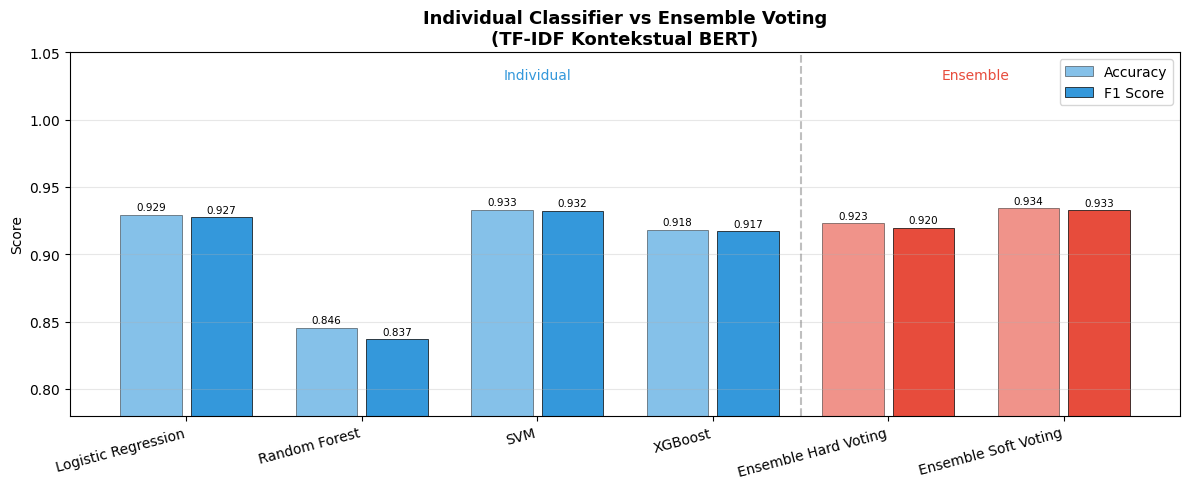

In [34]:
# ============================================================
# VISUALISASI FINAL — INDIVIDUAL vs ENSEMBLE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_results = {
    **individual_results,
    'Ensemble Hard Voting': {
        'accuracy' : acc_hard,  'precision': prec_hard,
        'recall'   : rec_hard,  'f1'       : f1_hard,
        'y_pred'   : y_pred_hard
    },
    'Ensemble Soft Voting': {
        'accuracy' : acc_soft,  'precision': prec_soft,
        'recall'   : rec_soft,  'f1'       : f1_soft,
        'y_pred'   : y_pred_soft
    }
}

# --- Bar Chart Perbandingan F1 ---
fig, ax = plt.subplots(figsize=(12, 5))

names_all = list(all_results.keys())
f1_vals   = [all_results[n]['f1'] for n in names_all]
acc_vals  = [all_results[n]['accuracy'] for n in names_all]

colors = ['#3498db'] * 4 + ['#e74c3c', '#e74c3c']  # biru=individual, merah=ensemble
x = np.arange(len(names_all))

bars = ax.bar(x - 0.2, acc_vals, 0.35, label='Accuracy',
              color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + 0.2, f1_vals, 0.35, label='F1 Score',
               color=colors, edgecolor='black', linewidth=0.5)

for bar in list(bars) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(names_all, rotation=15, ha='right')
ax.set_ylim(0.78, 1.05)
ax.set_ylabel('Score')
ax.set_title('Individual Classifier vs Ensemble Voting\n(TF-IDF Kontekstual BERT)',
             fontsize=13, fontweight='bold')
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2.0, 1.03, 'Individual', ha='center', fontsize=10, color='#3498db')
ax.text(4.5, 1.03, 'Ensemble', ha='center', fontsize=10, color='#e74c3c')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('individual_vs_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

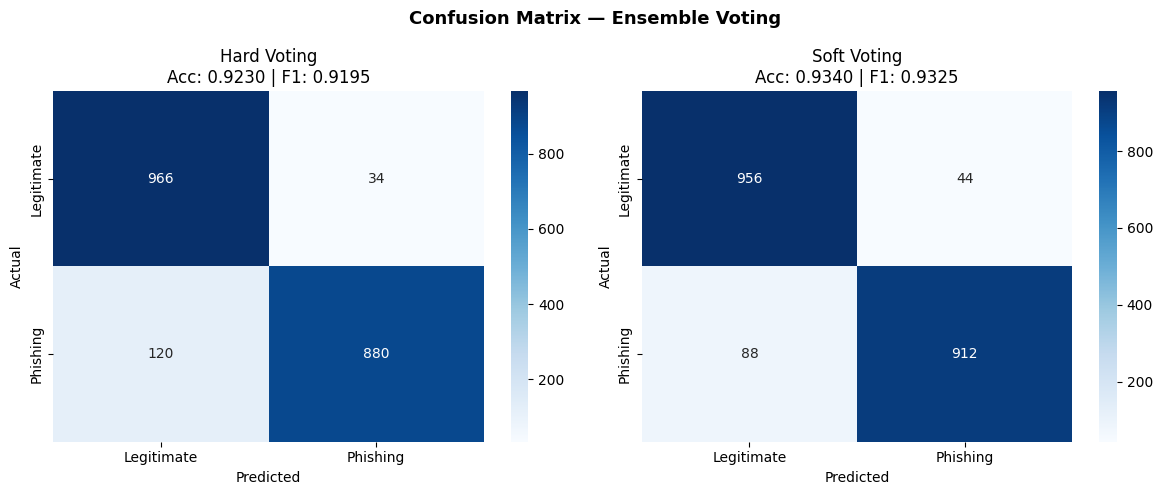


✅ Semua visualisasi tersimpan!
🚀 Eksperimen selesai


In [35]:
# --- Confusion Matrix Ensemble ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — Ensemble Voting', fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, [
    ('Hard Voting', y_pred_hard),
    ('Soft Voting', y_pred_soft)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc: {acc:.4f} | F1: {f1:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua visualisasi tersimpan!")
print("🚀 Eksperimen selesai")

# BERT Fine Tuning Classifier

In [36]:
# ============================================================
# PERSIAPAN BERT FINE-TUNING CLASSIFIER
# ============================================================

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
import time

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("✅ Tokenizer siap!")


✅ Device: cuda
✅ Tokenizer siap!


In [37]:
import os
# Cek file yang dibutuhkan
required = ['df_clean.csv', 'X_train.pkl', 'X_val.pkl', 'X_test.pkl',
            'y_train.pkl', 'y_val.pkl', 'y_test.pkl', 'tfidf_vectorizer.pkl']

print("📋 Cek file:")
for f in required:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"   {status} {f}")

# Cek variabel penting
print("\n📋 Cek variabel:")
for var in ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test',
            'url_train', 'url_val', 'url_test']:
    status = "✅" if var in dir() else "❌"
    print(f"   {status} {var}")

📋 Cek file:
   ✅ df_clean.csv
   ✅ X_train.pkl
   ✅ X_val.pkl
   ✅ X_test.pkl
   ✅ y_train.pkl
   ✅ y_val.pkl
   ✅ y_test.pkl
   ✅ tfidf_vectorizer.pkl

📋 Cek variabel:
   ✅ X_train
   ✅ X_val
   ✅ X_test
   ✅ y_train
   ✅ y_val
   ✅ y_test
   ✅ url_train
   ✅ url_val
   ✅ url_test


In [38]:
# Load url splits (kalau belum ada di memori)
import joblib
import pandas as pd

df = pd.read_csv('df_clean.csv')
url_array = df['URL_clean'].values
y         = df['label'].values

from sklearn.model_selection import train_test_split
url_temp, url_test, y_temp, y_test = train_test_split(
    url_array, y, test_size=0.2, random_state=42, stratify=y
)
url_train, url_val, y_train, y_val = train_test_split(
    url_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"\n✅ Data splits siap!")
print(f"   Train : {len(url_train):,}")
print(f"   Val   : {len(url_val):,}")
print(f"   Test  : {len(url_test):,}")


✅ Data splits siap!
   Train : 7,000
   Val   : 1,000
   Test  : 2,000


In [39]:
# ============================================================
# DATASET CLASS UNTUK BERT
# ============================================================
# Kita buatkan "wadah" khusus yang bisa dibaca
# oleh BERT saat training — berisi URL + label + tokenisasi

class PhishingDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length=128):
        self.urls      = urls
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url   = str(self.urls[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            url,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(label, dtype=torch.long)
        }


# Buat dataset
train_dataset = PhishingDataset(url_train, y_train, tokenizer)
val_dataset   = PhishingDataset(url_val,   y_val,   tokenizer)
test_dataset  = PhishingDataset(url_test,  y_test,  tokenizer)

# Buat dataloader (batch processing)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("✅ Dataset & DataLoader siap!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ Dataset & DataLoader siap!
   Train batches : 219
   Val batches   : 32
   Test batches  : 63


In [40]:
# ============================================================
# LOAD MODEL BERT UNTUK KLASIFIKASI
# ============================================================
# BertForSequenceClassification = BERT + layer klasifikasi di atasnya
# num_labels=2 → phishing atau legitimate

bert_clf = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
bert_clf = bert_clf.to(device)

# Optimizer & scheduler
optimizer = AdamW(bert_clf.parameters(), lr=2e-5, weight_decay=0.01)

epochs     = 3  # 3 epoch cukup untuk fine-tuning BERT
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print("✅ BERT Classifier siap!")
print(f"   Total training steps : {total_steps:,}")
print(f"   Epochs               : {epochs}")
print(f"   Batch size           : 32")
print(f"   Learning rate        : 2e-5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT Classifier siap!
   Total training steps : 657
   Epochs               : 3
   Batch size           : 32
   Learning rate        : 2e-5


In [41]:
# ============================================================
# TRAINING BERT FINE-TUNING
# ============================================================
# estimasi 15-30 menit di GPU Colab

def evaluate_bert(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids  = batch['input_ids'].to(device)
            attn_mask  = batch['attention_mask'].to(device)
            labels     = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attn_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    return acc, f1, all_preds, all_labels


# Training loop
print("⏳ Mulai training BERT Fine-tuning...")
print(f"   Estimasi waktu: 15-30 menit (GPU) / 60-90 menit (CPU)\n")

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1    = 0
best_model_state = None

for epoch in range(epochs):
    bert_clf.train()
    total_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader):
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = bert_clf(input_ids=input_ids,
                           attention_mask=attn_mask,
                           labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_clf.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (step + 1) % 50 == 0:
            print(f"   Epoch {epoch+1} | Step {step+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}", end='\r')

    # Evaluasi di val set setiap epoch
    avg_loss = total_loss / len(train_loader)
    val_acc, val_f1, _, _ = evaluate_bert(bert_clf, val_loader, device)
    elapsed  = time.time() - start

    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\n📊 Epoch {epoch+1}/{epochs} ({elapsed:.0f}s)")
    print(f"   Train Loss : {avg_loss:.4f}")
    print(f"   Val Acc    : {val_acc:.4f}")
    print(f"   Val F1     : {val_f1:.4f}")

    # Simpan model terbaik berdasarkan val F1
    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_model_state = bert_clf.state_dict().copy()
        print(f"   ✅ Model terbaik disimpan! (Val F1: {best_val_f1:.4f})")

print(f"\n🏆 Training selesai! Best Val F1: {best_val_f1:.4f}")

⏳ Mulai training BERT Fine-tuning...
   Estimasi waktu: 15-30 menit (GPU) / 60-90 menit (CPU)


📊 Epoch 1/3 (158s)
   Train Loss : 0.3509
   Val Acc    : 0.9320
   Val F1     : 0.9312
   ✅ Model terbaik disimpan! (Val F1: 0.9312)

📊 Epoch 2/3 (156s)
   Train Loss : 0.1428
   Val Acc    : 0.9460
   Val F1     : 0.9443
   ✅ Model terbaik disimpan! (Val F1: 0.9443)

📊 Epoch 3/3 (155s)
   Train Loss : 0.0796
   Val Acc    : 0.9540
   Val F1     : 0.9531
   ✅ Model terbaik disimpan! (Val F1: 0.9531)

🏆 Training selesai! Best Val F1: 0.9531


📊 BERT Fine-tuning — Hasil Evaluasi Final (Test Set)
              precision    recall  f1-score   support

  Legitimate       0.92      0.97      0.94      1000
    Phishing       0.97      0.91      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

✅ bert_classifier.pt tersimpan!


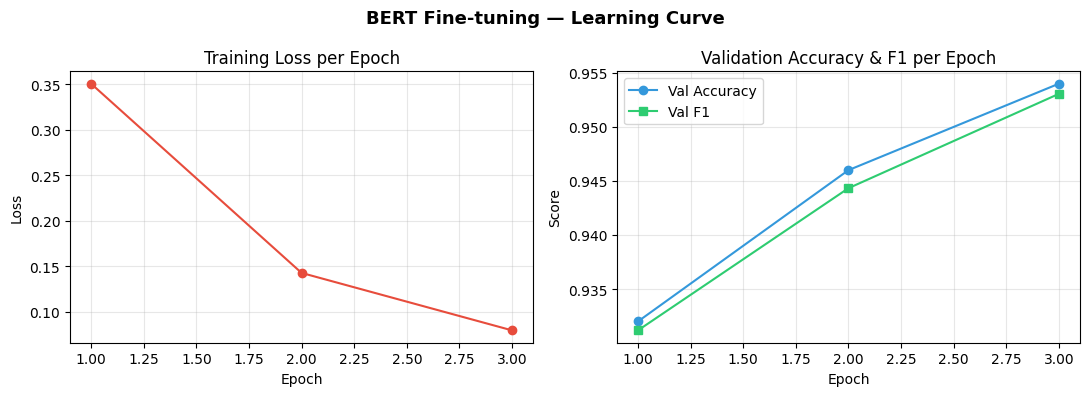

In [42]:
# ============================================================
# EVALUASI FINAL BERT DI TEST SET
# ============================================================

# Load model terbaik
bert_clf.load_state_dict(best_model_state)

# Evaluasi di test set
test_acc, test_f1, y_pred_bert, y_true_bert = evaluate_bert(
    bert_clf, test_loader, device
)

prec_bert = precision_score(y_true_bert, y_pred_bert)
rec_bert  = recall_score(y_true_bert, y_pred_bert)

print("=" * 55)
print("📊 BERT Fine-tuning — Hasil Evaluasi Final (Test Set)")
print("=" * 55)
print(classification_report(y_true_bert, y_pred_bert,
      target_names=['Legitimate', 'Phishing']))

# Simpan model
torch.save(best_model_state, 'bert_classifier.pt')
print("✅ bert_classifier.pt tersimpan!")

# Learning curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('BERT Fine-tuning — Learning Curve', fontsize=13, fontweight='bold')

axes[0].plot(range(1, epochs+1), history['train_loss'],
             marker='o', color='#e74c3c', label='Train Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs+1), history['val_acc'],
             marker='o', color='#3498db', label='Val Accuracy')
axes[1].plot(range(1, epochs+1), history['val_f1'],
             marker='s', color='#2ecc71', label='Val F1')
axes[1].set_title('Validation Accuracy & F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bert_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


MODEL                      ACCURACY  PRECISION   RECALL       F1
Logistic Regression          0.9330     0.9148   0.9550   0.9344
Random Forest                0.8525     0.8243   0.8960   0.8586
SVM                          0.9420     0.9333   0.9520   0.9426 ⭐
XGBoost                      0.9195     0.9030   0.9400   0.9211
Ensemble Hard Voting         0.9295     0.9240   0.9360   0.9300
Ensemble Soft Voting         0.9375     0.9219   0.9560   0.9386
BERT Fine-tuning             0.9400     0.9661   0.9120   0.9383


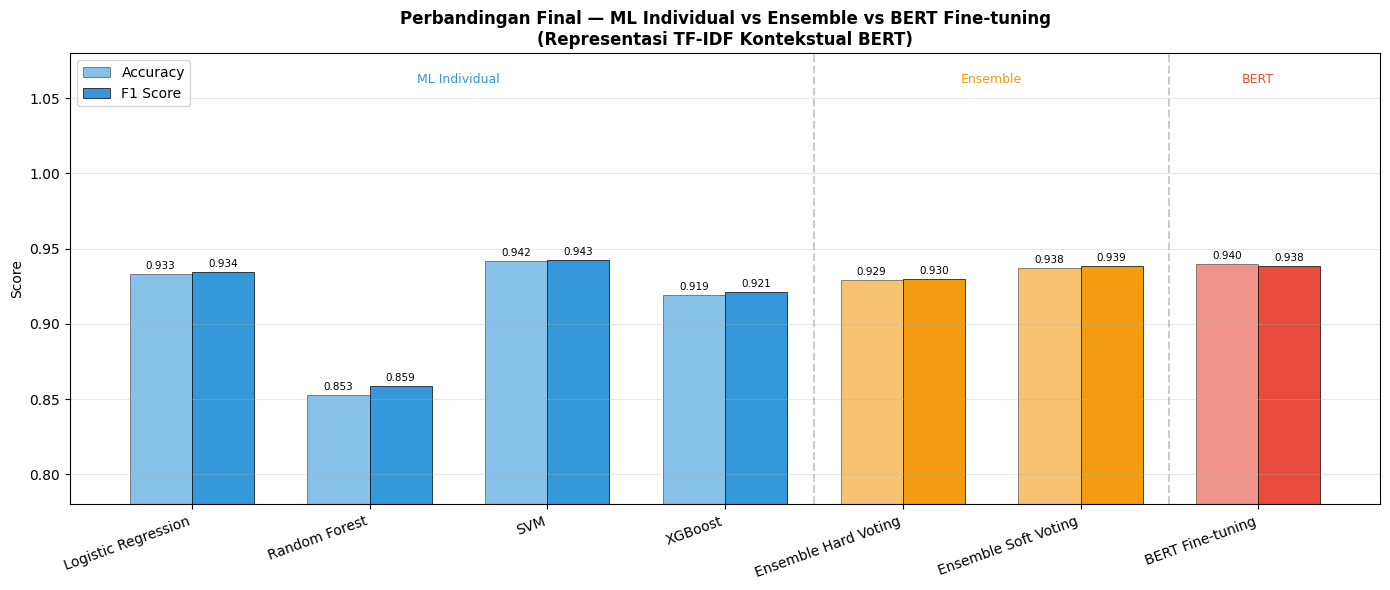


✅ Visualisasi final tersimpan!
🎉 Eksperimen selesai! Semua model sudah dibandingkan.


In [43]:
# ============================================================
# PERBANDINGAN FINAL SEMUA MODEL
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_final = {
    'Logistic Regression'  : {'accuracy': 0.9330, 'precision': 0.9148, 'recall': 0.9550, 'f1': 0.9344},
    'Random Forest'        : {'accuracy': 0.8525, 'precision': 0.8243, 'recall': 0.8960, 'f1': 0.8586},
    'SVM'                  : {'accuracy': 0.9420, 'precision': 0.9333, 'recall': 0.9520, 'f1': 0.9426},
    'XGBoost'              : {'accuracy': 0.9195, 'precision': 0.9030, 'recall': 0.9400, 'f1': 0.9211},
    'Ensemble Hard Voting' : {'accuracy': 0.9295, 'precision': 0.9240, 'recall': 0.9360, 'f1': 0.9300},
    'Ensemble Soft Voting' : {'accuracy': 0.9375, 'precision': 0.9219, 'recall': 0.9560, 'f1': 0.9386},
    'BERT Fine-tuning'     : {'accuracy': test_acc, 'precision': prec_bert,
                              'recall': rec_bert, 'f1': test_f1},
}

print("\n" + "=" * 72)
print(f"{'MODEL':<25} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 72)

for name, res in all_final.items():
    marker = " ⭐" if res['f1'] == max(r['f1'] for r in all_final.values()) else ""
    print(f"{name:<25} {res['accuracy']:>9.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f}{marker}")

print("=" * 72)

# Bar chart F1 semua model
names_all = list(all_final.keys())
f1_vals   = [all_final[n]['f1'] for n in names_all]
acc_vals  = [all_final[n]['accuracy'] for n in names_all]
colors    = ['#3498db']*4 + ['#f39c12']*2 + ['#e74c3c']

x     = np.arange(len(names_all))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy',
            color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, f1_vals,  width, label='F1 Score',
            color=colors, edgecolor='black', linewidth=0.5)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(names_all, rotation=20, ha='right')
ax.set_ylim(0.78, 1.08)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Final — ML Individual vs Ensemble vs BERT Fine-tuning\n'
             '(Representasi TF-IDF Kontekstual BERT)',
             fontsize=12, fontweight='bold')
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1.5,  1.06, 'ML Individual', ha='center', fontsize=9, color='#3498db')
ax.text(4.5,  1.06, 'Ensemble',      ha='center', fontsize=9, color='#f39c12')
ax.text(6.0,  1.06, 'BERT',          ha='center', fontsize=9, color='#e74c3c')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_semua_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualisasi final tersimpan!")
print("🎉 Eksperimen selesai! Semua model sudah dibandingkan.")

In [44]:
# Cek variabel
vars_needed = ['url_train', 'url_val', 'url_test',
               'y_train', 'y_val', 'y_test',
               'X_train', 'X_test', 'bert_clf',
               'y_pred_bert', 'y_true_bert']

print("📋 Cek variabel:")
for var in vars_needed:
    status = "✅" if var in dir() else "❌"
    print(f"   {status} {var}")

# Cek file
print("\n📋 Cek file:")
files_needed = ['df_clean.csv', 'X_train.pkl', 'X_test.pkl',
                'bert_classifier.pt', 'tfidf_vectorizer.pkl']
for f in files_needed:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"   {status} {f}")

📋 Cek variabel:
   ✅ url_train
   ✅ url_val
   ✅ url_test
   ✅ y_train
   ✅ y_val
   ✅ y_test
   ✅ X_train
   ✅ X_test
   ✅ bert_clf
   ✅ y_pred_bert
   ✅ y_true_bert

📋 Cek file:
   ✅ df_clean.csv
   ✅ X_train.pkl
   ✅ X_test.pkl
   ✅ bert_classifier.pt
   ✅ tfidf_vectorizer.pkl


In [45]:
X_train = joblib.load('X_train.pkl')
X_val   = joblib.load('X_val.pkl')
X_test  = joblib.load('X_test.pkl')

print("✅ Data berhasil dimuat!")
print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

✅ Data berhasil dimuat!
   X_train : (7000, 5768)
   X_val   : (1000, 5768)
   X_test  : (2000, 5768)


In [46]:
# ============================================================
# DISTILBERT FINE-TUNING
# ============================================================

from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch
import time

# Load tokenizer distilBERT
print("⏳ Loading DistilBERT...")
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("✅ DistilBERT tokenizer siap!")

# Buat dataset (reuse class PhishingDataset dari Cell 22)
train_dataset_db = PhishingDataset(url_train, y_train, distilbert_tokenizer)
val_dataset_db   = PhishingDataset(url_val,   y_val,   distilbert_tokenizer)
test_dataset_db  = PhishingDataset(url_test,  y_test,  distilbert_tokenizer)

train_loader_db  = DataLoader(train_dataset_db, batch_size=32, shuffle=True)
val_loader_db    = DataLoader(val_dataset_db,   batch_size=32, shuffle=False)
test_loader_db   = DataLoader(test_dataset_db,  batch_size=32, shuffle=False)

print(f"✅ Dataset siap!")
print(f"   Train batches : {len(train_loader_db)}")
print(f"   Val batches   : {len(val_loader_db)}")
print(f"   Test batches  : {len(test_loader_db)}")

⏳ Loading DistilBERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ DistilBERT tokenizer siap!
✅ Dataset siap!
   Train batches : 219
   Val batches   : 32
   Test batches  : 63


In [47]:
# ============================================================
# TRAINING DISTILBERT
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

distilbert_clf = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
distilbert_clf = distilbert_clf.to(device)

optimizer_db  = AdamW(distilbert_clf.parameters(), lr=2e-5, weight_decay=0.01)
epochs        = 3
total_steps_db = len(train_loader_db) * epochs

scheduler_db = get_linear_schedule_with_warmup(
    optimizer_db,
    num_warmup_steps=total_steps_db // 10,
    num_training_steps=total_steps_db
)

print("⏳ Training DistilBERT...")
print(f"   Estimasi: 10-20 menit (lebih cepat dari BERT)\n")

history_db       = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1_db   = 0
best_state_db    = None

for epoch in range(epochs):
    distilbert_clf.train()
    total_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader_db):
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['label'].to(device)

        optimizer_db.zero_grad()
        outputs = distilbert_clf(input_ids=input_ids,
                                 attention_mask=attn_mask,
                                 labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(distilbert_clf.parameters(), 1.0)
        optimizer_db.step()
        scheduler_db.step()

        if (step + 1) % 50 == 0:
            print(f"   Epoch {epoch+1} | Step {step+1}/{len(train_loader_db)} "
                  f"| Loss: {loss.item():.4f}", end='\r')

    avg_loss = total_loss / len(train_loader_db)
    val_acc, val_f1, _, _ = evaluate_bert(distilbert_clf, val_loader_db, device)
    elapsed  = time.time() - start

    history_db['train_loss'].append(avg_loss)
    history_db['val_acc'].append(val_acc)
    history_db['val_f1'].append(val_f1)

    print(f"\n📊 Epoch {epoch+1}/{epochs} ({elapsed:.0f}s)")
    print(f"   Train Loss : {avg_loss:.4f}")
    print(f"   Val Acc    : {val_acc:.4f}")
    print(f"   Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1_db:
        best_val_f1_db = val_f1
        best_state_db  = distilbert_clf.state_dict().copy()
        print(f"   ✅ Model terbaik disimpan! (Val F1: {best_val_f1_db:.4f})")

print(f"\n🏆 DistilBERT selesai! Best Val F1: {best_val_f1_db:.4f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


⏳ Training DistilBERT...
   Estimasi: 10-20 menit (lebih cepat dari BERT)


📊 Epoch 1/3 (79s)
   Train Loss : 0.3303
   Val Acc    : 0.9330
   Val F1     : 0.9316
   ✅ Model terbaik disimpan! (Val F1: 0.9316)

📊 Epoch 2/3 (79s)
   Train Loss : 0.1355
   Val Acc    : 0.9410
   Val F1     : 0.9408
   ✅ Model terbaik disimpan! (Val F1: 0.9408)

📊 Epoch 3/3 (78s)
   Train Loss : 0.0801
   Val Acc    : 0.9470
   Val F1     : 0.9474
   ✅ Model terbaik disimpan! (Val F1: 0.9474)

🏆 DistilBERT selesai! Best Val F1: 0.9474


In [48]:
# ============================================================
# EVALUASI DISTILBERT
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

distilbert_clf.load_state_dict(best_state_db)

test_acc_db, test_f1_db, y_pred_db, y_true_db = evaluate_bert(
    distilbert_clf, test_loader_db, device
)

prec_db = precision_score(y_true_db, y_pred_db)
rec_db  = recall_score(y_true_db, y_pred_db)

print("=" * 55)
print("📊 DistilBERT — Hasil Evaluasi Final (Test Set)")
print("=" * 55)
print(classification_report(y_true_db, y_pred_db,
      target_names=['Legitimate', 'Phishing']))

torch.save(best_state_db, 'distilbert_classifier.pt')
print("✅ distilbert_classifier.pt tersimpan!")

📊 DistilBERT — Hasil Evaluasi Final (Test Set)
              precision    recall  f1-score   support

  Legitimate       0.94      0.95      0.94      1000
    Phishing       0.95      0.94      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

✅ distilbert_classifier.pt tersimpan!


In [49]:
# ============================================================
# ROBERTA FINE-TUNING
# ============================================================

from transformers import (RobertaTokenizer,
                          RobertaForSequenceClassification)

print("⏳ Loading RoBERTa...")
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
print("✅ RoBERTa tokenizer siap!")

train_dataset_rb = PhishingDataset(url_train, y_train, roberta_tokenizer)
val_dataset_rb   = PhishingDataset(url_val,   y_val,   roberta_tokenizer)
test_dataset_rb  = PhishingDataset(url_test,  y_test,  roberta_tokenizer)

train_loader_rb  = DataLoader(train_dataset_rb, batch_size=32, shuffle=True)
val_loader_rb    = DataLoader(val_dataset_rb,   batch_size=32, shuffle=False)
test_loader_rb   = DataLoader(test_dataset_rb,  batch_size=32, shuffle=False)

print(f"✅ Dataset RoBERTa siap!")

⏳ Loading RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ RoBERTa tokenizer siap!
✅ Dataset RoBERTa siap!


In [50]:
# ============================================================
# TRAINING ROBERTA
# ============================================================

roberta_clf = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
)
roberta_clf = roberta_clf.to(device)

optimizer_rb   = AdamW(roberta_clf.parameters(), lr=2e-5, weight_decay=0.01)
total_steps_rb = len(train_loader_rb) * epochs

scheduler_rb = get_linear_schedule_with_warmup(
    optimizer_rb,
    num_warmup_steps=total_steps_rb // 10,
    num_training_steps=total_steps_rb
)

print("⏳ Training RoBERTa...")
print(f"   Estimasi: 20-35 menit (lebih berat dari BERT)\n")

history_rb      = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1_rb  = 0
best_state_rb   = None

for epoch in range(epochs):
    roberta_clf.train()
    total_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader_rb):
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['label'].to(device)

        optimizer_rb.zero_grad()
        outputs = roberta_clf(input_ids=input_ids,
                              attention_mask=attn_mask,
                              labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(roberta_clf.parameters(), 1.0)
        optimizer_rb.step()
        scheduler_rb.step()

        if (step + 1) % 50 == 0:
            print(f"   Epoch {epoch+1} | Step {step+1}/{len(train_loader_rb)} "
                  f"| Loss: {loss.item():.4f}", end='\r')

    avg_loss = total_loss / len(train_loader_rb)
    val_acc, val_f1, _, _ = evaluate_bert(roberta_clf, val_loader_rb, device)
    elapsed  = time.time() - start

    history_rb['train_loss'].append(avg_loss)
    history_rb['val_acc'].append(val_acc)
    history_rb['val_f1'].append(val_f1)

    print(f"\n📊 Epoch {epoch+1}/{epochs} ({elapsed:.0f}s)")
    print(f"   Train Loss : {avg_loss:.4f}")
    print(f"   Val Acc    : {val_acc:.4f}")
    print(f"   Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1_rb:
        best_val_f1_rb = val_f1
        best_state_rb  = roberta_clf.state_dict().copy()
        print(f"   ✅ Model terbaik disimpan! (Val F1: {best_val_f1_rb:.4f})")

print(f"\n🏆 RoBERTa selesai! Best Val F1: {best_val_f1_rb:.4f}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


⏳ Training RoBERTa...
   Estimasi: 20-35 menit (lebih berat dari BERT)


📊 Epoch 1/3 (157s)
   Train Loss : 0.3174
   Val Acc    : 0.9450
   Val F1     : 0.9456
   ✅ Model terbaik disimpan! (Val F1: 0.9456)

📊 Epoch 2/3 (155s)
   Train Loss : 0.1388
   Val Acc    : 0.9550
   Val F1     : 0.9536
   ✅ Model terbaik disimpan! (Val F1: 0.9536)

📊 Epoch 3/3 (155s)
   Train Loss : 0.0857
   Val Acc    : 0.9630
   Val F1     : 0.9621
   ✅ Model terbaik disimpan! (Val F1: 0.9621)

🏆 RoBERTa selesai! Best Val F1: 0.9621


In [51]:
# ============================================================
# EVALUASI ROBERTA
# ============================================================

roberta_clf.load_state_dict(best_state_rb)

test_acc_rb, test_f1_rb, y_pred_rb, y_true_rb = evaluate_bert(
    roberta_clf, test_loader_rb, device
)

prec_rb = precision_score(y_true_rb, y_pred_rb)
rec_rb  = recall_score(y_true_rb, y_pred_rb)

print("=" * 55)
print("📊 RoBERTa — Hasil Evaluasi Final (Test Set)")
print("=" * 55)
print(classification_report(y_true_rb, y_pred_rb,
      target_names=['Legitimate', 'Phishing']))

torch.save(best_state_rb, 'roberta_classifier.pt')
print("✅ roberta_classifier.pt tersimpan!")

📊 RoBERTa — Hasil Evaluasi Final (Test Set)
              precision    recall  f1-score   support

  Legitimate       0.93      0.98      0.96      1000
    Phishing       0.98      0.93      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.95      0.95      2000

✅ roberta_classifier.pt tersimpan!


📊 ANALISIS ERROR — TRANSFORMER MODELS
Model         Total Error  False Pos  False Neg  Error Rate
-------------------------------------------------------
BERT                  120         32         88        6.0%
DistilBERT            111         48         63        5.5%
RoBERTa                92         21         71        4.6%

🔍 Contoh URL salah klasifikasi (BERT):

  False Positive (Legitimate dikira Phishing):
    • fo-t.com/eng/user/...
    • mountainhardwear.com/on/demandware.store/sites-mountainhardwear_us-sit...
    • tefillinbankafrica.co.za/...
    • money.cnn.com/pf/features/lists/global_gasprices/...
    • karasu.mur.at/...

  False Negative (Phishing lolos sebagai Legitimate):
    • uzbekistan-mfa.com/...
    • safeadspace.com/...
    • www.vianneylebasque.com/smallbusinessonlinecommunity.bankofamerica.com...
    • mosedo.com/form.asp.htm...
    • battcave.net/ksrwo...


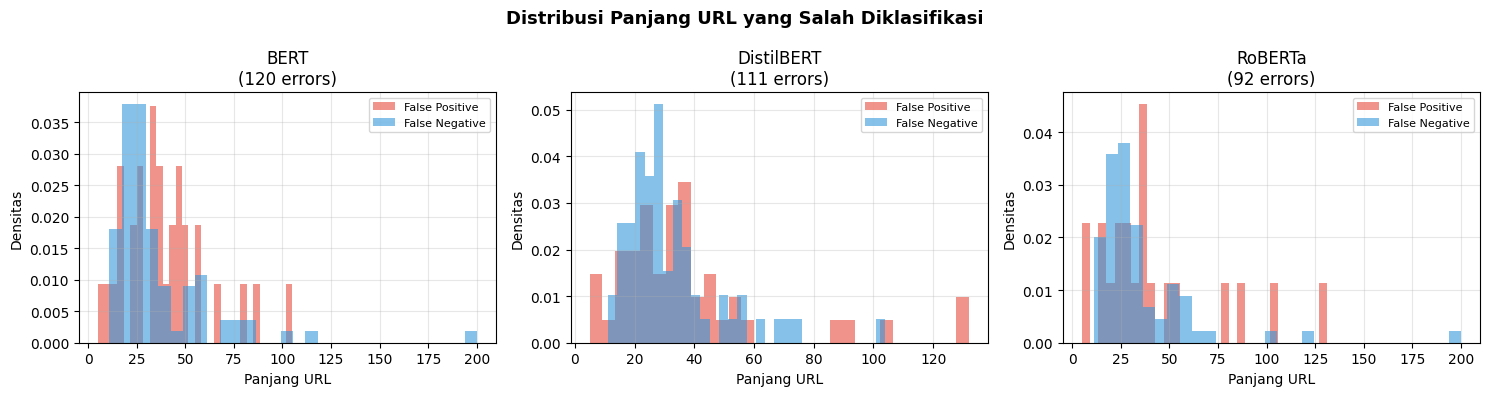

In [52]:
# ============================================================
# ANALISIS ERROR — URL YANG SALAH DIKLASIFIKASI
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Ambil URL test
url_test_list = list(url_test)

# Fungsi analisis error per model
def analyze_errors(model_name, url_list, y_true, y_pred):
    errors = []
    for i, (url, true, pred) in enumerate(zip(url_list, y_true, y_pred)):
        if true != pred:
            errors.append({
                'url'       : url,
                'actual'    : 'Phishing' if true == 1 else 'Legitimate',
                'predicted' : 'Phishing' if pred == 1 else 'Legitimate',
                'error_type': 'False Positive' if pred == 1 else 'False Negative',
                'url_length': len(url)
            })
    return pd.DataFrame(errors)


# Analisis error semua transformer model
errors_bert     = analyze_errors('BERT',      url_test_list, y_true_bert, y_pred_bert)
errors_db       = analyze_errors('DistilBERT', url_test_list, y_true_db,   y_pred_db)
errors_rb       = analyze_errors('RoBERTa',   url_test_list, y_true_rb,   y_pred_rb)

print("=" * 55)
print("📊 ANALISIS ERROR — TRANSFORMER MODELS")
print("=" * 55)
print(f"{'Model':<12} {'Total Error':>12} {'False Pos':>10} {'False Neg':>10} {'Error Rate':>11}")
print("-" * 55)

for name, errors, total in [
    ('BERT',       errors_bert, len(y_true_bert)),
    ('DistilBERT', errors_db,   len(y_true_db)),
    ('RoBERTa',    errors_rb,   len(y_true_rb))
]:
    fp = len(errors[errors['error_type'] == 'False Positive'])
    fn = len(errors[errors['error_type'] == 'False Negative'])
    er = len(errors) / total * 100
    print(f"{name:<12} {len(errors):>12} {fp:>10} {fn:>10} {er:>10.1f}%")

print("=" * 55)

# Contoh URL yang sering salah diklasifikasi oleh BERT
print(f"\n🔍 Contoh URL salah klasifikasi (BERT):")
print(f"\n  False Positive (Legitimate dikira Phishing):")
fp_examples = errors_bert[errors_bert['error_type'] == 'False Positive'].head(5)
for _, row in fp_examples.iterrows():
    print(f"    • {row['url'][:70]}...")

print(f"\n  False Negative (Phishing lolos sebagai Legitimate):")
fn_examples = errors_bert[errors_bert['error_type'] == 'False Negative'].head(5)
for _, row in fn_examples.iterrows():
    print(f"    • {row['url'][:70]}...")


# Visualisasi distribusi panjang URL yang salah
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Panjang URL yang Salah Diklasifikasi',
             fontsize=13, fontweight='bold')

for ax, (name, errors) in zip(axes, [
    ('BERT', errors_bert), ('DistilBERT', errors_db), ('RoBERTa', errors_rb)
]):
    for etype, color in [('False Positive', '#e74c3c'), ('False Negative', '#3498db')]:
        subset = errors[errors['error_type'] == etype]['url_length']
        if len(subset) > 0:
            subset.clip(upper=200).hist(bins=30, alpha=0.6, color=color,
                                        label=etype, ax=ax, density=True)
    ax.set_title(f'{name}\n({len(errors)} errors)')
    ax.set_xlabel('Panjang URL')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_error_url.png', dpi=150, bbox_inches='tight')
plt.show()

📊 HASIL EKSPERIMEN KITA
MODEL                      ACCURACY  PRECISION   RECALL       F1
Logistic Regression          0.9330     0.9148   0.9550   0.9344
Random Forest                0.8525     0.8243   0.8960   0.8586
SVM                          0.9420     0.9333   0.9520   0.9426
XGBoost                      0.9195     0.9030   0.9400   0.9211
Ensemble Hard Voting         0.9295     0.9240   0.9360   0.9300
Ensemble Soft Voting         0.9375     0.9219   0.9560   0.9386
BERT Fine-tuning             0.9430     0.9179   0.9730   0.9447
DistilBERT                   0.9445     0.9513   0.9370   0.9441
RoBERTa                      0.9540     0.9779   0.9290   0.9528 ⭐

📚 PERBANDINGAN DENGAN JURNAL
MODEL                     DATASET       ACCURACY       F1
BERT Fine-tuning          URL (Kita)      0.9430   0.9447
BERT (Jurnal)             Email (Jurnal)    0.9911   0.9922
  Selisih                                -0.0481  -0.0475
-------------------------------------------------------
Dist

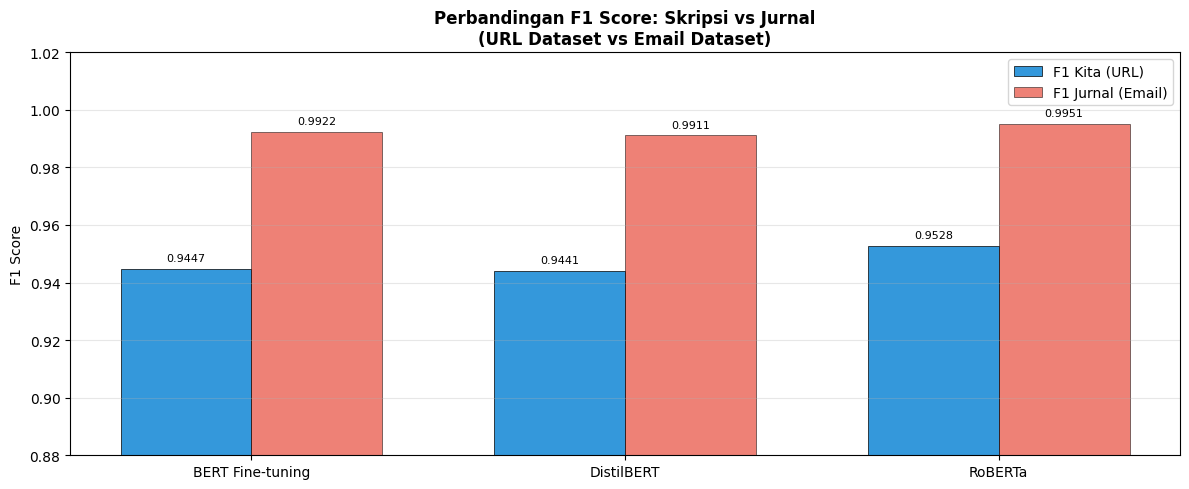


✅ Semua visualisasi tersimpan!

🎉 EKSPERIMEN LENGKAP SELESAI!
   Download semua file hasil sebelum session habis!


In [53]:
# ============================================================
# PERBANDINGAN FINAL SEMUA MODEL + PAPER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Semua hasil eksperimen kita
hasil_kita = {
    'Logistic Regression'  : {'accuracy': 0.9330, 'precision': 0.9148, 'recall': 0.9550, 'f1': 0.9344},
    'Random Forest'        : {'accuracy': 0.8525, 'precision': 0.8243, 'recall': 0.8960, 'f1': 0.8586},
    'SVM'                  : {'accuracy': 0.9420, 'precision': 0.9333, 'recall': 0.9520, 'f1': 0.9426},
    'XGBoost'              : {'accuracy': 0.9195, 'precision': 0.9030, 'recall': 0.9400, 'f1': 0.9211},
    'Ensemble Hard Voting' : {'accuracy': 0.9295, 'precision': 0.9240, 'recall': 0.9360, 'f1': 0.9300},
    'Ensemble Soft Voting' : {'accuracy': 0.9375, 'precision': 0.9219, 'recall': 0.9560, 'f1': 0.9386},
    'BERT Fine-tuning'     : {'accuracy': 0.9430, 'precision': 0.9179, 'recall': 0.9730, 'f1': 0.9447},
    'DistilBERT'           : {'accuracy': test_acc_db, 'precision': prec_db,
                              'recall': rec_db, 'f1': test_f1_db},
    'RoBERTa'              : {'accuracy': test_acc_rb, 'precision': prec_rb,
                              'recall': rec_rb, 'f1': test_f1_rb},
}

# Hasil dari jurnal (pembanding)
hasil_jurnal = {
    'BERT (Jurnal)'        : {'accuracy': 0.9911, 'f1': 0.9922},
    'DistilBERT (Jurnal)'  : {'accuracy': 0.9899, 'f1': 0.9911},
    'RoBERTa (Jurnal)'     : {'accuracy': 0.9943, 'f1': 0.9951},
}

# Tabel perbandingan hasil kita
print("=" * 72)
print("📊 HASIL EKSPERIMEN KITA")
print(f"{'MODEL':<25} {'ACCURACY':>9} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("=" * 72)
best_f1 = max(v['f1'] for v in hasil_kita.values())
for name, res in hasil_kita.items():
    marker = " ⭐" if res['f1'] == best_f1 else ""
    print(f"{name:<25} {res['accuracy']:>9.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f}{marker}")
print("=" * 72)

# Tabel perbandingan dengan jurnal
print("\n" + "=" * 55)
print("📚 PERBANDINGAN DENGAN JURNAL")
print(f"{'MODEL':<25} {'DATASET':<12} {'ACCURACY':>9} {'F1':>8}")
print("=" * 55)

jurnal_map = {
    'BERT Fine-tuning' : 'BERT (Jurnal)',
    'DistilBERT'       : 'DistilBERT (Jurnal)',
    'RoBERTa'          : 'RoBERTa (Jurnal)',
}

for our_name, jurnal_name in jurnal_map.items():
    our  = hasil_kita[our_name]
    jur  = hasil_jurnal[jurnal_name]
    print(f"{our_name:<25} {'URL (Kita)':<12} {our['accuracy']:>9.4f} {our['f1']:>8.4f}")
    print(f"{jurnal_name:<25} {'Email (Jurnal)':<12} {jur['accuracy']:>9.4f} {jur['f1']:>8.4f}")
    diff_acc = our['accuracy'] - jur['accuracy']
    diff_f1  = our['f1'] - jur['f1']
    print(f"  {'Selisih':<23} {'':<12} {diff_acc:>+9.4f} {diff_f1:>+8.4f}")
    print("-" * 55)

# Visualisasi perbandingan transformer models
fig, ax = plt.subplots(figsize=(12, 5))

transformer_models = ['BERT Fine-tuning', 'DistilBERT', 'RoBERTa']
jurnal_models      = ['BERT (Jurnal)', 'DistilBERT (Jurnal)', 'RoBERTa (Jurnal)']

x     = np.arange(len(transformer_models))
width = 0.35

f1_kita   = [hasil_kita[m]['f1']    for m in transformer_models]
acc_kita  = [hasil_kita[m]['accuracy'] for m in transformer_models]
f1_jurnal = [hasil_jurnal[m]['f1']  for m in jurnal_models]
acc_jurnal= [hasil_jurnal[m]['accuracy'] for m in jurnal_models]

b1 = ax.bar(x - width/2, f1_kita,   width, label='F1 Kita (URL)',
            color='#3498db', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, f1_jurnal, width, label='F1 Jurnal (Email)',
            color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(transformer_models)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel('F1 Score')
ax.set_title('Perbandingan F1 Score: Skripsi vs Jurnal\n'
             '(URL Dataset vs Email Dataset)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_jurnal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua visualisasi tersimpan!")
print("\n🎉 EKSPERIMEN LENGKAP SELESAI!")
print("   Download semua file hasil sebelum session habis!")

# Testing

In [55]:
# ============================================================
# TESTING MODEL DENGAN URL BARU
# ============================================================

import torch
import numpy as np
import scipy.sparse as sp
from sklearn.preprocessing import normalize
from transformers import (BertTokenizer, BertForSequenceClassification,
                          RobertaTokenizer, RobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Fungsi prediksi untuk Transformer models ----
def predict_transformer(url, model, tokenizer, device, max_length=128):
    model.eval()
    url_clean = url.encode('ascii', errors='ignore').decode('ascii').strip().lower()

    encoding = tokenizer(
        url_clean,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred    = np.argmax(probs)

    return {
    'label'     : 'Phishing' if pred == 1 else 'Legitimate',
    'confidence': probs[pred] * 100,
    'prob_legit': probs[0] * 100,
    'prob_phish': probs[1] * 100
    }


# ---- Fungsi prediksi untuk ML models ----
def predict_ml(url, tfidf, bert_extractor, bert_tok, ml_models, device):
    url_clean = url.encode('ascii', errors='ignore').decode('ascii').strip().lower()

    # TF-IDF
    tfidf_vec = tfidf.transform([url_clean])

    # BERT embedding
    encoded = bert_tok(
        url_clean, max_length=128, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        output = bert_extractor(**encoded)
    bert_vec = output.last_hidden_state[:, 0, :].cpu().numpy()
    bert_vec = normalize(bert_vec)
    bert_sp  = sp.csr_matrix(bert_vec)

    # Gabungkan
    X = sp.hstack([tfidf_vec, bert_sp])

    results = {}
    for name, model in ml_models.items():
        pred = model.predict(X)[0]
        results[name] = 'Phishing' if pred == 1 else 'Legitimate'
    return results


print("✅ Fungsi prediksi siap!")

✅ Fungsi prediksi siap!


In [56]:
import os
print([f for f in os.listdir('.') if f.endswith('.pkl')])

['tfidf_vectorizer.pkl', 'X_val.pkl', 'logistic_regression.pkl', 'X_train.pkl', 'random_forest_tuned.pkl', 'ensemble_soft.pkl', 'svm.pkl', 'X_test.pkl', 'ensemble_hard.pkl', 'naive_bayes.pkl', 'y_test.pkl', 'y_val.pkl', 'y_train.pkl', 'random_forest.pkl', 'ensemble_best.pkl', 'xgboost.pkl']


In [57]:
# ============================================================
# LOAD SEMUA MODEL
# ============================================================

print("⏳ Loading semua model...")

# --- Transformer models ---
# BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_clf_test  = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2)
bert_clf_test.load_state_dict(torch.load('bert_classifier.pt', map_location=device))
bert_clf_test  = bert_clf_test.to(device)
print("✅ BERT loaded!")

# DistilBERT
distilbert_tok      = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_clf_test = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2)
distilbert_clf_test.load_state_dict(torch.load('distilbert_classifier.pt', map_location=device))
distilbert_clf_test = distilbert_clf_test.to(device)
print("✅ DistilBERT loaded!")

# RoBERTa
roberta_tok      = RobertaTokenizer.from_pretrained('roberta-base')
roberta_clf_test = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=2)
roberta_clf_test.load_state_dict(torch.load('roberta_classifier.pt', map_location=device))
roberta_clf_test = roberta_clf_test.to(device)
print("✅ RoBERTa loaded!")

# --- BERT sebagai feature extractor (untuk ML) ---
from transformers import BertModel
bert_extractor = BertModel.from_pretrained('bert-base-uncased')
bert_extractor = bert_extractor.to(device)
bert_extractor.eval()

# --- ML models ---
import joblib
ml_models = {
    'Logistic Regression': joblib.load('logistic_regression.pkl'),
    'SVM'                : joblib.load('svm.pkl'),
    'XGBoost'            : joblib.load('xgboost.pkl'),
    'Ensemble Soft'      : joblib.load('ensemble_soft.pkl'),
    'Ensemble Hard'      : joblib.load('ensemble_hard.pkl'),
    'Random Forest'      : joblib.load('random_forest.pkl')
}
tfidf = joblib.load('tfidf_vectorizer.pkl')

print("\n✅ Semua model berhasil dimuat!")

⏳ Loading semua model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT loaded!


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ RoBERTa loaded!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Semua model berhasil dimuat!


In [58]:
# ============================================================
# TEST URL BARU
# ============================================================

# Kumpulan URL test — campuran phishing dan legitimate
test_urls = [
    # Legitimate
    "google.com",
    "github.com/anthropics/claude",
    "tokopedia.com/product/laptop",
    "youtube.com/watch?v=abc123",
    "stackoverflow.com/questions/python",

    # Phishing
    "paypal-secure-login.com/verify/account",
    "google.com.login-secure.xyz/signin",
    "tokopedia-promo.free-voucher.ru/claim",
    "192.168.1.1/paypal/login/secure",
    "secure-bankbca-login.com/auth/verify?token=abc",

    # Ambigu (bisa jadi salah prediksi)
    "bit.ly/3xK9pLm",
    "tinyurl.com/promo-gratis",
    "drive.google.com.download-file.net/doc",
]

print("=" * 75)
print(f"{'URL':<45} {'BERT':>10} {'DistilBERT':>12} {'RoBERTa':>10}")
print("=" * 75)

all_predictions = []

for url in test_urls:
    # Prediksi transformer
    res_bert  = predict_transformer(url, bert_clf_test,      bert_tokenizer, device)
    res_db    = predict_transformer(url, distilbert_clf_test, distilbert_tok, device)
    res_rb    = predict_transformer(url, roberta_clf_test,   roberta_tok,    device)

    # Format output
    def fmt(res):
        icon = "🚨" if res['label'] == 'Phishing' else "✅"
        return f"{icon} {res['confidence']:.1f}%"

    url_short = url[:43] + '..' if len(url) > 43 else url
    print(f"{url_short:<45} {fmt(res_bert):>10} {fmt(res_db):>12} {fmt(res_rb):>10}")

    all_predictions.append({
        'url'       : url,
        'bert'      : res_bert['label'],
        'distilbert': res_db['label'],
        'roberta'   : res_rb['label'],
        'confidence_bert'  : res_bert['confidence'],
        'confidence_db'    : res_db['confidence'],
        'confidence_rb'    : res_rb['confidence'],
    })

print("=" * 75)
print("🚨 = Phishing   ✅ = Legitimate")

URL                                                 BERT   DistilBERT    RoBERTa
google.com                                       ✅ 96.5%      ✅ 99.2%    ✅ 91.1%
github.com/anthropics/claude                     ✅ 99.6%      ✅ 99.7%    ✅ 99.9%
tokopedia.com/product/laptop                     ✅ 98.9%      ✅ 99.2%    ✅ 99.8%
youtube.com/watch?v=abc123                       ✅ 99.7%      ✅ 99.7%    ✅ 99.9%
stackoverflow.com/questions/python               ✅ 83.6%      🚨 98.9%    ✅ 99.9%
paypal-secure-login.com/verify/account           🚨 99.7%      🚨 99.6%    🚨 99.9%
google.com.login-secure.xyz/signin               🚨 99.7%      🚨 99.6%    🚨 99.9%
tokopedia-promo.free-voucher.ru/claim            🚨 99.3%      🚨 98.8%    🚨 99.9%
192.168.1.1/paypal/login/secure                  🚨 99.7%      🚨 99.7%    🚨 99.9%
secure-bankbca-login.com/auth/verify?token=..    🚨 99.8%      🚨 99.6%    🚨 99.9%
bit.ly/3xK9pLm                                   🚨 99.8%      🚨 99.7%    🚨 99.6%
tinyurl.com/promo-gratis    

In [59]:
# ============================================================
# ANALISIS PREDIKSI + VOTING ENSEMBLE TRANSFORMER
# ============================================================

print("\n📊 DETAIL PREDIKSI + CONFIDENCE SCORE")
print("=" * 75)

for pred in all_predictions:
    url_short = pred['url'][:50] + '..' if len(pred['url']) > 50 else pred['url']

    # Majority voting dari 3 transformer
    votes = [pred['bert'], pred['distilbert'], pred['roberta']]
    phish_votes = votes.count('Phishing')
    final = 'Phishing' if phish_votes >= 2 else 'Legitimate'
    icon  = "🚨" if final == 'Phishing' else "✅"

    # Cek apakah semua model setuju
    agree = "✅ Semua setuju" if len(set(votes)) == 1 else f"⚠️  Tidak setuju ({phish_votes}/3)"

    print(f"\n  URL     : {url_short}")
    print(f"  BERT    : {pred['bert']:<12} ({pred['confidence_bert']:.1f}%)")
    print(f"  DistilBERT: {pred['distilbert']:<12} ({pred['confidence_db']:.1f}%)")
    print(f"  RoBERTa : {pred['roberta']:<12} ({pred['confidence_rb']:.1f}%)")
    print(f"  Final   : {icon} {final} | {agree}")
    print(f"  {'-'*60}")


📊 DETAIL PREDIKSI + CONFIDENCE SCORE

  URL     : google.com
  BERT    : Legitimate   (96.5%)
  DistilBERT: Legitimate   (99.2%)
  RoBERTa : Legitimate   (91.1%)
  Final   : ✅ Legitimate | ✅ Semua setuju
  ------------------------------------------------------------

  URL     : github.com/anthropics/claude
  BERT    : Legitimate   (99.6%)
  DistilBERT: Legitimate   (99.7%)
  RoBERTa : Legitimate   (99.9%)
  Final   : ✅ Legitimate | ✅ Semua setuju
  ------------------------------------------------------------

  URL     : tokopedia.com/product/laptop
  BERT    : Legitimate   (98.9%)
  DistilBERT: Legitimate   (99.2%)
  RoBERTa : Legitimate   (99.8%)
  Final   : ✅ Legitimate | ✅ Semua setuju
  ------------------------------------------------------------

  URL     : youtube.com/watch?v=abc123
  BERT    : Legitimate   (99.7%)
  DistilBERT: Legitimate   (99.7%)
  RoBERTa : Legitimate   (99.9%)
  Final   : ✅ Legitimate | ✅ Semua setuju
  ---------------------------------------------------

In [60]:
# Cek mapping label di dataset
import pandas as pd
df = pd.read_csv('df_clean.csv')
print(df[['Label', 'label']].value_counts())

Label  label
bad    1        5000
good   0        5000
Name: count, dtype: int64


In [69]:
# ============================================================
# CELL 38: TEST URL BARU — TRANSFORMER + ML
# ============================================================

test_urls = [
    # Legitimate
    "google.com",
    "github.com/anthropics/claude",
    "tokopedia.com/product/laptop",
    "youtube.com/watch?v=abc123",
    "stackoverflow.com/questions/python",
    # Phishing
    "paypal-secure-login.com/verify/account",
    "google.com.login-secure.xyz/signin",
    "tokopedia-promo.free-voucher.ru/claim",
    "192.168.1.1/paypal/login/secure",
    "secure-bankbca-login.com/auth/verify?token=abc",
    # Ambigu
    "bit.ly/3xK9pLm",
    "tinyurl.com/promo-gratis",
    "drive.google.com.download-file.net/doc",
]

all_predictions = []

for url in test_urls:
    # --- Prediksi Transformer ---
    res_bert = predict_transformer(url, bert_clf_test,       bert_tokenizer, device)
    res_db   = predict_transformer(url, distilbert_clf_test, distilbert_tok, device)
    res_rb   = predict_transformer(url, roberta_clf_test,    roberta_tok,    device)

    # --- Prediksi ML ---
    res_ml   = predict_ml(url, tfidf, bert_extractor, bert_tokenizer, ml_models, device)

    all_predictions.append({
        'url'              : url,
        'bert'             : res_bert['label'],
        'distilbert'       : res_db['label'],
        'roberta'          : res_rb['label'],
        'confidence_bert'  : res_bert['confidence'],
        'confidence_db'    : res_db['confidence'],
        'confidence_rb'    : res_rb['confidence'],
        'ml'               : res_ml
    })


# ============================================================
# TAMPILKAN HASIL
# ============================================================

def icon(label):
    return "🚨" if label == 'Phishing' else "✅"

for pred in all_predictions:
    url_short = pred['url'][:60] + '..' if len(pred['url']) > 60 else pred['url']

    # Majority voting transformer
    votes      = [pred['bert'], pred['distilbert'], pred['roberta']]
    phish_votes = votes.count('Phishing')
    final_trans = 'Phishing' if phish_votes >= 2 else 'Legitimate'

    # Majority voting ML
    ml_votes      = list(pred['ml'].values())
    ml_phish      = ml_votes.count('Phishing')
    final_ml      = 'Phishing' if ml_phish >= 2 else 'Legitimate'

    print("=" * 65)
    print(f"🔗 URL: {url_short}")
    print(f"{'─'*65}")

    # Transformer results
    print(f"  📡 TRANSFORMER MODELS:")
    print(f"     BERT       : {icon(pred['bert'])} {pred['bert']:<12} ({pred['confidence_bert']:.1f}%)")
    print(f"     DistilBERT : {icon(pred['distilbert'])} {pred['distilbert']:<12} ({pred['confidence_db']:.1f}%)")
    print(f"     RoBERTa    : {icon(pred['roberta'])} {pred['roberta']:<12} ({pred['confidence_rb']:.1f}%)")
    agree_trans = "✅ Semua setuju" if len(set(votes)) == 1 else f"⚠️  Tidak setuju ({phish_votes}/3)"
    print(f"     → Final    : {icon(final_trans)} {final_trans} | {agree_trans}")

    print(f"{'─'*65}")

    # ML results
    print(f"  🤖 ML MODELS:")
    for ml_name, ml_label in pred['ml'].items():
        print(f"     {ml_name:<22}: {icon(ml_label)} {ml_label}")
    agree_ml = "✅ Semua setuju" if len(set(ml_votes)) == 1 else f"⚠️  Tidak setuju ({ml_phish}/{len(ml_votes)})"
    print(f"     → Final    : {icon(final_ml)} {final_ml} | {agree_ml}")

    print(f"{'─'*65}")

    # Kesimpulan akhir (gabungan transformer + ML voting)
    all_votes   = votes + ml_votes
    total_phish = all_votes.count('Phishing')
    final_all   = 'Phishing' if total_phish >= len(all_votes) // 2 + 1 else 'Legitimate'
    print(f"  🎯 KEPUTUSAN AKHIR: {icon(final_all)} {final_all} "
          f"({total_phish}/{len(all_votes)} model setuju phishing)")

print("=" * 65)
print("🚨 = Phishing   ✅ = Legitimate")

🔗 URL: google.com
─────────────────────────────────────────────────────────────────
  📡 TRANSFORMER MODELS:
     BERT       : ✅ Legitimate   (96.5%)
     DistilBERT : ✅ Legitimate   (99.2%)
     RoBERTa    : ✅ Legitimate   (91.1%)
     → Final    : ✅ Legitimate | ✅ Semua setuju
─────────────────────────────────────────────────────────────────
  🤖 ML MODELS:
     Logistic Regression   : 🚨 Phishing
     SVM                   : 🚨 Phishing
     XGBoost               : ✅ Legitimate
     Ensemble Soft         : 🚨 Phishing
     Ensemble Hard         : ✅ Legitimate
     Random Forest         : ✅ Legitimate
     → Final    : 🚨 Phishing | ⚠️  Tidak setuju (3/6)
─────────────────────────────────────────────────────────────────
  🎯 KEPUTUSAN AKHIR: ✅ Legitimate (3/9 model setuju phishing)
🔗 URL: github.com/anthropics/claude
─────────────────────────────────────────────────────────────────
  📡 TRANSFORMER MODELS:
     BERT       : ✅ Legitimate   (99.6%)
     DistilBERT : ✅ Legitimate   (99.7%)
    

In [64]:
from google.colab import files
import os
import time

def download_batch(file_list, batch_name):
    print(f"\n📦 {batch_name}")
    print("=" * 40)
    for f in file_list:
        if os.path.exists(f):
            files.download(f)
            time.sleep(1)  # jeda lebih lama
            print(f"✅ {f}")
        else:
            print(f"❌ {f} tidak ditemukan")

In [65]:
# BATCH 1 — Model Transformer
download_batch([
    'bert_classifier.pt',
    'distilbert_classifier.pt',
    'roberta_classifier.pt',
], "BATCH 1: Model Transformer")


📦 BATCH 1: Model Transformer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ bert_classifier.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ distilbert_classifier.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ roberta_classifier.pt


In [66]:
# BATCH 2 — Model ML
download_batch([
    'logistic_regression.pkl',
    'svm.pkl',
    'xgboost.pkl',
    'random_forest.pkl',
    'random_forest_tuned.pkl',
    'naive_bayes.pkl',
    'ensemble_soft.pkl',
    'ensemble_hard.pkl',
    'ensemble_best.pkl',
], "BATCH 2: Model ML")


📦 BATCH 2: Model ML


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ logistic_regression.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ ensemble_hard.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ensemble_best.pkl


In [67]:
# BATCH 3 — Data
download_batch([
    'df_clean.csv',
    'X_train.pkl',
    'X_val.pkl',
    'X_test.pkl',
    'y_train.pkl',
    'y_val.pkl',
    'y_test.pkl',
    'tfidf_vectorizer.pkl',
], "BATCH 3: Data")


📦 BATCH 3: Data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ df_clean.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ y_test.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ tfidf_vectorizer.pkl


In [68]:
# BATCH 4 — Visualisasi
download_batch([
    'distribusi_data.png',
    'overfit_check.png',
    'confusion_matrix_ml.png',
    'confusion_matrix_final.png',
    'confusion_matrix_ensemble.png',
    'perbandingan_model_ml.png',
    'perbandingan_final_ml.png',
    'perbandingan_semua_model.png',
    'perbandingan_jurnal.png',
    'individual_vs_ensemble.png',
    'analisis_error_url.png',
    'bert_learning_curve.png',
], "BATCH 4: Visualisasi")


📦 BATCH 4: Visualisasi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ distribusi_data.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ analisis_error_url.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ bert_learning_curve.png
